In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ============================================================
# CELL 1 — SETUP & LOAD DATA
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import random

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Your actual Google Drive folder
DATA_PATH = "/content/drive/MyDrive/Datathon_2026"

# Load the 5 datasets
carbon = pd.read_csv(f"{DATA_PATH}/carbon_prices_daily.csv")
events = pd.read_csv(f"{DATA_PATH}/climate_events.csv")
co2 = pd.read_csv(f"{DATA_PATH}/co2_emissions_yearly.csv")
energy = pd.read_csv(f"{DATA_PATH}/energy_mix_yearly.csv")
temp = pd.read_csv(f"{DATA_PATH}/temperature_anomaly_monthly.csv")

datasets = {
    "Carbon Prices": carbon,
    "Climate Events": events,
    "CO2 Emissions": co2,
    "Energy Mix": energy,
    "Temperature Anomaly": temp
}

print("=" * 65)
print("CODEFEST DATATHON 2026 — DATA LOADING")
print("=" * 65)

for name, df in datasets.items():
    print(f"{name:<25}: {df.shape[0]:,} rows × {df.shape[1]} columns")

print("\n✅ ALL 5 DATASETS LOADED SUCCESSFULLY")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CODEFEST DATATHON 2026 — DATA LOADING
Carbon Prices            : 15,866 rows × 5 columns
Climate Events           : 50 rows × 11 columns
CO2 Emissions            : 1,350 rows × 8 columns
Energy Mix               : 1,350 rows × 14 columns
Temperature Anomaly      : 2,528 rows × 7 columns

✅ ALL 5 DATASETS LOADED SUCCESSFULLY


In [4]:
# ============================================================
# SECTION 2 — INITIAL DATA UNDERSTANDING
# ============================================================

for name, df in datasets.items():

    print("\n" + "=" * 90)
    print(f"DATASET: {name}")
    print("=" * 90)

    print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns")

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nFirst 5 Rows:")
    display(df.head())

    print("\nMissing Values:")
    missing = pd.DataFrame({
        "Missing_Count": df.isna().sum(),
        "Missing_%": (df.isna().mean() * 100).round(2)
    })

    display(missing[missing["Missing_Count"] > 0])

    print(f"\nDuplicate rows: {df.duplicated().sum():,}")

    print("\nNumeric Summary:")
    display(df.describe().T)


DATASET: Carbon Prices

Shape: 15,866 rows × 5 columns

Columns:
['date', 'year', 'market', 'currency', 'price']

Data Types:
date         object
year          int64
market       object
currency     object
price       float64
dtype: object

First 5 Rows:


,date,year,market,currency,price
0,2005-04-22,2005,EU_ETS,EUR,7.17
1,2005-04-25,2005,EU_ETS,EUR,7.13
2,2005-04-26,2005,EU_ETS,EUR,7.44
3,2005-04-27,2005,EU_ETS,EUR,7.38
4,2005-04-28,2005,EU_ETS,EUR,7.38



Missing Values:


,Missing_Count,Missing_%



Duplicate rows: 0

Numeric Summary:


...

,year_month,year,month,region,temp_anomaly_c,temp_anomaly_baseline,co2_ppm
0,2000-01,2000,1,Global,0.432,1951-1980,367.44
1,2000-01,2000,1,Arctic,1.500,1951-1980,NaN
2,2000-01,2000,1,Northern_Hemisphere,0.468,1951-1980,NaN
3,2000-01,2000,1,Southern_Hemisphere,0.320,1951-1980,NaN
4,2000-01,2000,1,Tropics,0.272,1951-1980,NaN



Missing Values:


,Missing_Count,Missing_%
co2_ppm,2212,87.5



Duplicate rows: 0

Numeric Summary:


,count,mean,std,min,25%,50%,75%,max
year,2528.0,2012.670886,7.605170,2000.000,2006.00000,2013.000,2019.00000,2026.000
month,2528.0,6.449367,3.462132,1.000,3.00000,6.000,9.00000,12.000
temp_anomaly_c,2528.0,1.125491,0.753221,0.219,0.64175,0.902,1.31625,4.522
co2_ppm,316.0,398.315190,19.775620,365.780,381.07250,394.320,415.88250,436.880


In [5]:
# ============================================================
# CELL 4 — DATA FORENSICS / QUALITY CHECKS
# ============================================================

# Convert dates safely
carbon["date"] = pd.to_datetime(carbon["date"])
events["date"] = pd.to_datetime(events["date"])
temp["year_month"] = pd.to_datetime(temp["year_month"])

print("=" * 70)
print("1. DATE / YEAR COVERAGE")
print("=" * 70)

for name, df, date_col in [
    ("Carbon Prices", carbon, "date"),
    ("Climate Events", events, "date"),
    ("Temperature", temp, "year_month")
]:
    print(
        f"{name:<20}: "
        f"{df[date_col].min().date()} → {df[date_col].max().date()}"
    )

print(f"CO2 Emissions       : {co2.year.min()} → {co2.year.max()}")
print(f"Energy Mix          : {energy.year.min()} → {energy.year.max()}")


# ------------------------------------------------------------
print("\n" + "=" * 70)
print("2. UNIQUE COUNTRIES / MARKETS / REGIONS")
print("=" * 70)

print("\nCarbon markets:")
print(carbon["market"].value_counts())

print("\nCO2 countries:", co2["country"].nunique())
print("Energy countries:", energy["country"].nunique())

print("\nCO2 regions:")
print(sorted(co2["region"].unique()))

print("\nEnergy regions:")
print(sorted(energy["region"].unique()))

print("\nTemperature regions:")
print(sorted(temp["region"].unique()))


# ------------------------------------------------------------
print("\n" + "=" * 70)
print("3. CO2 ↔ ENERGY JOIN CHECK")
print("=" * 70)

co2_keys = set(zip(co2["iso3"], co2["year"]))
energy_keys = set(zip(energy["iso3"], energy["year"]))

print("CO2 country-year keys   :", len(co2_keys))
print("Energy country-year keys:", len(energy_keys))
print("Matching keys           :", len(co2_keys & energy_keys))
print("Only in CO2             :", len(co2_keys - energy_keys))
print("Only in Energy          :", len(energy_keys - co2_keys))


# ------------------------------------------------------------
print("\n" + "=" * 70)
print("4. ENERGY SHARE VALIDATION")
print("=" * 70)

base_shares = [
    "coal_pct",
    "oil_pct",
    "gas_pct",
    "nuclear_pct",
    "hydro_pct",
    "solar_pct",
    "wind_pct",
    "other_renewables_pct"
]

energy["calculated_total_share"] = energy[base_shares].sum(axis=1)

print(energy["calculated_total_share"].describe())

print(
    "\nRows outside 99–101%:",
    (~energy["calculated_total_share"].between(99, 101)).sum()
)

print(
    "Negative component values:",
    (energy[base_shares] < 0).sum().sum()
)

print(
    "Component values >100:",
    (energy[base_shares] > 100).sum().sum()
)


# ------------------------------------------------------------
print("\n" + "=" * 70)
print("5. DERIVED ENERGY TOTAL CONSISTENCY")
print("=" * 70)

calc_renewables = (
    energy["hydro_pct"]
    + energy["solar_pct"]
    + energy["wind_pct"]
    + energy["other_renewables_pct"]
)

calc_fossil = (
    energy["coal_pct"]
    + energy["oil_pct"]
    + energy["gas_pct"]
)

print(
    "Max renewable-total difference:",
    (calc_renewables - energy["renewables_total_pct"]).abs().max()
)

print(
    "Max fossil-total difference:",
    (calc_fossil - energy["fossil_total_pct"]).abs().max()
)


# ------------------------------------------------------------
print("\n" + "=" * 70)
print("6. CO2 VALIDITY CHECK")
print("=" * 70)

co2_numeric = [
    "co2_emissions_mt",
    "population_millions",
    "co2_per_capita_t",
    "co2_intensity_kg_per_gdp_usd"
]

for col in co2_numeric:
    print(
        f"{col:<35} "
        f"negative={(co2[col] < 0).sum():<5} "
        f"zero={(co2[col] == 0).sum():<5}"
    )


# ------------------------------------------------------------
print("\n" + "=" * 70)
print("7. WHY IS CO2_PPM MISSING?")
print("=" * 70)

ppm_check = (
    temp.groupby("region")["co2_ppm"]
        .agg(["count", "size"])
        .assign(
            missing=lambda x: x["size"] - x["count"],
            available_pct=lambda x:
                (100 * x["count"] / x["size"]).round(2)
        )
)

display(ppm_check)


# ------------------------------------------------------------
print("\n" + "=" * 70)
print("8. 2026 COVERAGE")
print("=" * 70)

print("Carbon 2026 rows :", (carbon["year"] == 2026).sum())
print("Events 2026 rows :", (events["year"] == 2026).sum())
print("CO2 2026 rows    :", (co2["year"] == 2026).sum())
print("Energy 2026 rows :", (energy["year"] == 2026).sum())
print("Temp 2026 rows   :", (temp["year"] == 2026).sum())

print("\nLatest carbon date:", carbon["date"].max())
print("Latest temp month :", temp["year_month"].max())

1. DATE / YEAR COVERAGE
Carbon Prices       : 2005-04-22 → 2026-04-30
Climate Events      : 2003-08-01 → 2026-04-10
Temperature         : 2000-01-01 → 2026-04-01
CO2 Emissions       : 2000 → 2026
Energy Mix          : 2000 → 2026

2. UNIQUE COUNTRIES / MARKETS / REGIONS

Carbon markets:
market
EU_ETS        5485
RGGI          4591
California    3248
UK_ETS        1292
China_ETS     1250
Name: count, dtype: int64

CO2 countries: 50
Energy countries: 50

CO2 regions:
['Africa', 'Asia', 'Eurasia', 'Europe', 'LatAm', 'MENA', 'North America', 'Oceania']

Energy regions:
['Africa', 'Asia', 'Eurasia', 'Europe', 'LatAm', 'MENA', 'North America', 'Oceania']

Temperature regions:
['Arctic', 'Asia', 'Europe', 'Global', 'North_America', 'Northern_Hemisphere', 'Southern_Hemisphere', 'Tropics']

3. CO2 ↔ ENERGY JOIN CHECK
CO2 country-year keys   : 1350
Energy country-year keys: 1350
Matching keys           : 1350
Only in CO2             : 0
Only in Energy          : 0

4. ENERGY SHARE VALIDATION
cou

,count,size,missing,available_pct
region,,,,
Arctic,0,316,316,0.0
Asia,0,316,316,0.0
Europe,0,316,316,0.0
Global,316,316,0,100.0
North_America,0,316,316,0.0
Northern_Hemisphere,0,316,316,0.0
Southern_Hemisphere,0,316,316,0.0
Tropics,0,316,316,0.0



8. 2026 COVERAGE
Carbon 2026 rows : 430
Events 2026 rows : 2
CO2 2026 rows    : 50
Energy 2026 rows : 50
Temp 2026 rows   : 32

Latest carbon date: 2026-04-30 00:00:00
Latest temp month : 2026-04-01 00:00:00


In [6]:
# ============================================================
# CELL 5 — DEEP DATA FORENSICS
# ============================================================

print("=" * 75)
print("A. CARBON PRICE — MARKET LEVEL CHECK")
print("=" * 75)

carbon_market_summary = carbon.groupby("market").agg(
    start_date=("date", "min"),
    end_date=("date", "max"),
    observations=("price", "size"),
    min_price=("price", "min"),
    median_price=("price", "median"),
    mean_price=("price", "mean"),
    max_price=("price", "max")
).round(2)

display(carbon_market_summary)


# ============================================================
# B. CHECK DATE ORDER + DUPLICATE MARKET-DATES
# ============================================================

print("\n" + "=" * 75)
print("B. CARBON MARKET-DATE INTEGRITY")
print("=" * 75)

market_date_duplicates = carbon.duplicated(
    subset=["market", "date"]
).sum()

print("Duplicate market-date combinations:",
      market_date_duplicates)

for market, g in carbon.groupby("market"):
    g = g.sort_values("date")

    print(
        f"{market:<15} "
        f"{g['date'].min().date()} → {g['date'].max().date()} | "
        f"{len(g):,} observations"
    )


# ============================================================
# C. PRICE RETURN / EXTREME MOVEMENT CHECK
# ============================================================

print("\n" + "=" * 75)
print("C. CARBON PRICE MOVEMENTS")
print("=" * 75)

carbon = carbon.sort_values(["market", "date"]).copy()

carbon["return_pct"] = (
    carbon.groupby("market")["price"]
          .pct_change(fill_method=None) * 100
)

return_summary = carbon.groupby("market")["return_pct"].agg(
    mean="mean",
    std="std",
    min="min",
    max="max"
).round(2)

display(return_summary)

print("\nLargest absolute daily movements:")

display(
    carbon.assign(
        abs_return=carbon["return_pct"].abs()
    )
    .sort_values("abs_return", ascending=False)
    [["date", "market", "price", "return_pct"]]
    .head(15)
)


# ============================================================
# D. ENERGY TOTAL ERROR — ROUNDING CHECK
# ============================================================

print("\n" + "=" * 75)
print("D. ENERGY SHARE ROUNDING")
print("=" * 75)

energy["share_error"] = (
    energy["calculated_total_share"] - 100
)

print(energy["share_error"].describe())

print(
    "\nMaximum absolute rounding error:",
    energy["share_error"].abs().max()
)


# ============================================================
# E. CO2 INTERNAL CONSISTENCY
# ============================================================

print("\n" + "=" * 75)
print("E. CO2 INTERNAL CONSISTENCY")
print("=" * 75)

# Mt CO2 / million people = tonnes per person
co2["calculated_co2_pc"] = (
    co2["co2_emissions_mt"] /
    co2["population_millions"]
)

co2["co2_pc_error"] = (
    co2["calculated_co2_pc"] -
    co2["co2_per_capita_t"]
)

print(co2["co2_pc_error"].abs().describe())

print(
    "\nMaximum absolute difference:",
    co2["co2_pc_error"].abs().max()
)


# ============================================================
# F. TEST WHETHER CO2 IS STRONGLY RELATED TO ENERGY MIX
# ============================================================

print("\n" + "=" * 75)
print("F. ENERGY MIX ↔ CO2 CORRELATIONS")
print("=" * 75)

merged = energy.merge(
    co2[
        [
            "year",
            "iso3",
            "co2_per_capita_t",
            "co2_emissions_mt"
        ]
    ],
    on=["year", "iso3"],
    how="inner"
)

energy_cols = [
    "coal_pct",
    "oil_pct",
    "gas_pct",
    "nuclear_pct",
    "hydro_pct",
    "solar_pct",
    "wind_pct",
    "other_renewables_pct",
    "renewables_total_pct",
    "fossil_total_pct"
]

corr = (
    merged[energy_cols + ["co2_per_capita_t"]]
    .corr()["co2_per_capita_t"]
    .drop("co2_per_capita_t")
    .sort_values(ascending=False)
)

display(corr.to_frame("Correlation_with_CO2_per_capita"))


# ============================================================
# G. 2026 ANNUAL DATA CHECK
# ============================================================

print("\n" + "=" * 75)
print("G. 2025 VS 2026 ANNUAL DATA")
print("=" * 75)

annual_check = (
    co2[co2["year"].isin([2025, 2026])]
    .groupby("year")
    .agg(
        countries=("iso3", "nunique"),
        mean_co2_pc=("co2_per_capita_t", "mean"),
        mean_emissions=("co2_emissions_mt", "mean")
    )
    .round(3)
)

display(annual_check)


# ============================================================
# H. BASIC COUNTRY-YEAR CONTINUITY
# ============================================================

print("\n" + "=" * 75)
print("H. COUNTRY YEAR CONTINUITY")
print("=" * 75)

expected_years = set(range(2000, 2027))

countries_with_missing_years = {}

for country, g in energy.groupby("iso3"):
    actual = set(g["year"])
    missing = expected_years - actual

    if missing:
        countries_with_missing_years[country] = sorted(missing)

print(
    "Countries with missing years:",
    len(countries_with_missing_years)
)

if countries_with_missing_years:
    print(countries_with_missing_years)
else:
    print("✓ Every country has complete annual coverage 2000–2026.")

A. CARBON PRICE — MARKET LEVEL CHECK


,start_date,end_date,observations,min_price,median_price,mean_price,max_price
market,,,,,,,
California,2013-11-19,2026-04-30,3248,9.49,16.19,20.38,37.82
China_ETS,2021-07-16,2026-04-30,1250,45.44,76.77,79.19,119.52
EU_ETS,2005-04-22,2026-04-30,5485,0.05,15.96,29.00,104.04
RGGI,2008-09-25,2026-04-30,4591,1.79,4.94,7.61,22.22
UK_ETS,2021-05-19,2026-04-30,1292,33.09,47.81,55.29,99.21



B. CARBON MARKET-DATE INTEGRITY
Duplicate market-date combinations: 0
California      2013-11-19 → 2026-04-30 | 3,248 observations
China_ETS       2021-07-16 → 2026-04-30 | 1,250 observations
EU_ETS          2005-04-22 → 2026-04-30 | 5,485 observations
RGGI            2008-09-25 → 2026-04-30 | 4,591 observations
UK_ETS          2021-05-19 → 2026-04-30 | 1,292 observations

C. CARBON PRICE MOVEMENTS


,mean,std,min,max
market,,,,
California,0.10,3.53,-13.17,13.12
China_ETS,0.14,3.67,-10.69,12.72
EU_ETS,0.16,5.45,-73.68,260.00
RGGI,0.11,3.61,-12.53,12.44
UK_ETS,0.06,3.49,-10.45,10.32



Largest absolute daily movements:


...


D. ENERGY SHARE ROUNDING
count    1.350000e+03
mean    -2.888889e-04
std      8.176488e-03
min     -2.000000e-02
25%     -1.000000e-02
50%      0.000000e+00
75%      1.421085e-14
max      2.000000e-02
Name: share_error, dtype: float64

Maximum absolute rounding error: 0.020000000000024443

E. CO2 INTERNAL CONSISTENCY
count    1350.000000
mean        0.017859
std         0.054522
min         0.000000
25%         0.001740
50%         0.004016
75%         0.009762
max         0.624138
Name: co2_pc_error, dtype: float64

Maximum absolute difference: 0.6241379310344826

F. ENERGY MIX ↔ CO2 CORRELATIONS


,Correlation_with_CO2_per_capita
gas_pct,0.467401
fossil_total_pct,0.395369
oil_pct,0.177253
nuclear_pct,0.055769
solar_pct,-0.018121
wind_pct,-0.132958
coal_pct,-0.175651
other_renewables_pct,-0.396369
hydro_pct,-0.444990
renewables_total_pct,-0.450160



G. 2025 VS 2026 ANNUAL DATA


,countries,mean_co2_pc,mean_emissions
year,,,
2025,50,7.315,697.066
2026,50,7.215,700.488



H. COUNTRY YEAR CONTINUITY
Countries with missing years: 0
✓ Every country has complete annual coverage 2000–2026.


In [7]:
# ============================================================
# CELL 6 — FINAL CLEANING
# ============================================================

# Create clean copies — never modify raw datasets directly
carbon_clean = carbon.copy()
events_clean = events.copy()
co2_clean = co2.copy()
energy_clean = energy.copy()
temp_clean = temp.copy()

# ------------------------------------------------------------
# 1. SORT TEMPORAL DATA
# ------------------------------------------------------------

carbon_clean = carbon_clean.sort_values(
    ["market", "date"]
).reset_index(drop=True)

events_clean = events_clean.sort_values(
    "date"
).reset_index(drop=True)

temp_clean = temp_clean.sort_values(
    ["region", "year_month"]
).reset_index(drop=True)

co2_clean = co2_clean.sort_values(
    ["iso3", "year"]
).reset_index(drop=True)

energy_clean = energy_clean.sort_values(
    ["iso3", "year"]
).reset_index(drop=True)


# ------------------------------------------------------------
# 2. REMOVE TEMPORARY AUDIT COLUMNS
# ------------------------------------------------------------

for col in ["return_pct"]:
    if col in carbon_clean.columns:
        carbon_clean.drop(columns=col, inplace=True)

for col in ["calculated_total_share", "share_error"]:
    if col in energy_clean.columns:
        energy_clean.drop(columns=col, inplace=True)

for col in ["calculated_co2_pc", "co2_pc_error"]:
    if col in co2_clean.columns:
        co2_clean.drop(columns=col, inplace=True)


# ------------------------------------------------------------
# 3. VALIDATE FINAL DATA
# ------------------------------------------------------------

clean_datasets = {
    "Carbon Prices": carbon_clean,
    "Climate Events": events_clean,
    "CO2 Emissions": co2_clean,
    "Energy Mix": energy_clean,
    "Temperature": temp_clean
}

print("=" * 75)
print("FINAL CLEANING SUMMARY")
print("=" * 75)

for name, df in clean_datasets.items():

    print(
        f"{name:<20} "
        f"Rows={len(df):>6,} | "
        f"Duplicates={df.duplicated().sum():>3} | "
        f"Missing={df.isna().sum().sum():>5}"
    )

print("\n✓ Raw observations preserved.")
print("✓ No unjustified outlier removal.")
print("✓ Structural CO2 ppm missingness preserved.")
print("✓ Temporal datasets sorted.")
print("✓ Audit-only columns removed.")

FINAL CLEANING SUMMARY
Carbon Prices        Rows=15,866 | Duplicates=  0 | Missing=    0
Climate Events       Rows=    50 | Duplicates=  0 | Missing=    0
CO2 Emissions        Rows= 1,350 | Duplicates=  0 | Missing=    0
Energy Mix           Rows= 1,350 | Duplicates=  0 | Missing=    0
Temperature          Rows= 2,528 | Duplicates=  0 | Missing= 2212

✓ Raw observations preserved.
✓ No unjustified outlier removal.
✓ Structural CO2 ppm missingness preserved.
✓ Temporal datasets sorted.
✓ Audit-only columns removed.


Cleaning Decisions

1. Duplicate removal:
   No duplicate observations were identified; therefore, no rows were removed.

2. Energy-share validation:
   Component shares ranged from 99.98% to 100.02% in total.
   These small differences were treated as rounding variation and retained.

3. Missing atmospheric CO₂:
   CO₂ ppm was available for the Global temperature series but structurally
   absent from regional series. These values were not imputed.

4. Carbon-price extremes:
   Extreme percentage changes, particularly in early EU ETS observations,
   were retained because low price levels can generate large percentage
   movements and they may represent genuine market behaviour.

5. Temporal ordering:
   All time-dependent datasets were chronologically sorted before subsequent
   feature engineering and validation.

6. Annual coverage:
   CO₂ and energy-mix datasets contain complete country-year coverage from
   2000–2026. 2026 annual observations are retained but flagged for careful
   interpretation because the daily/monthly datasets end in April 2026.

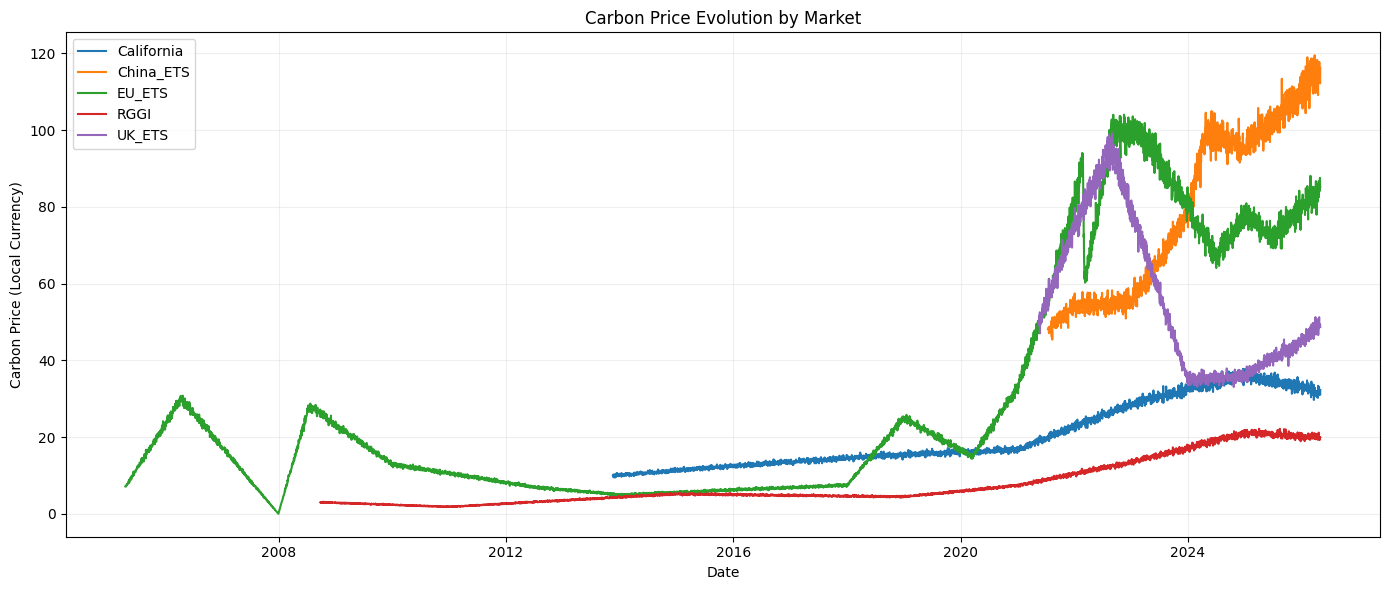

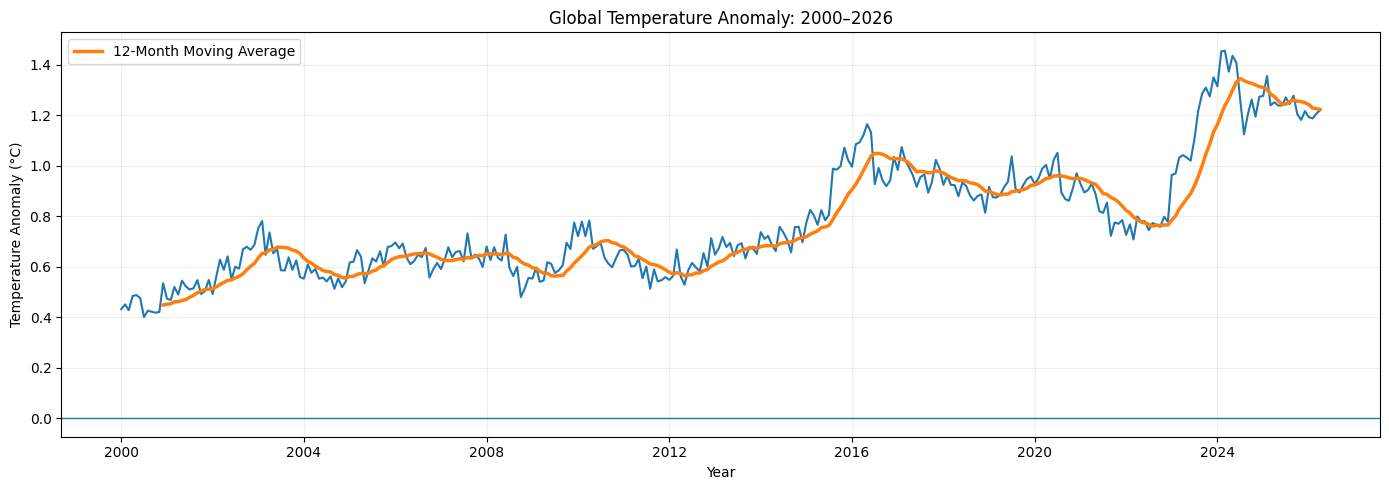

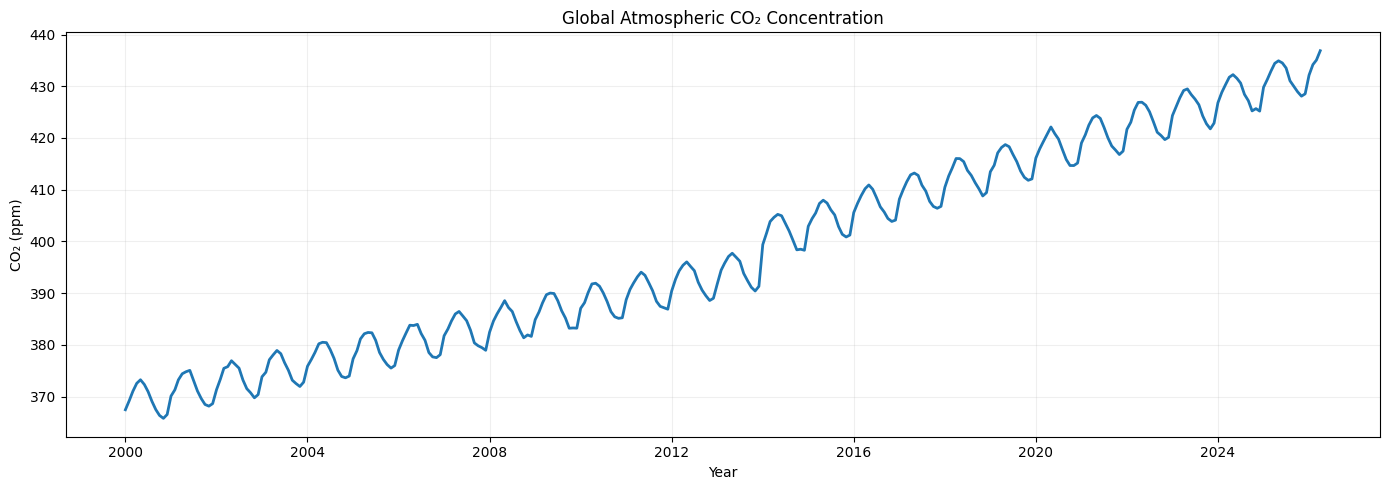

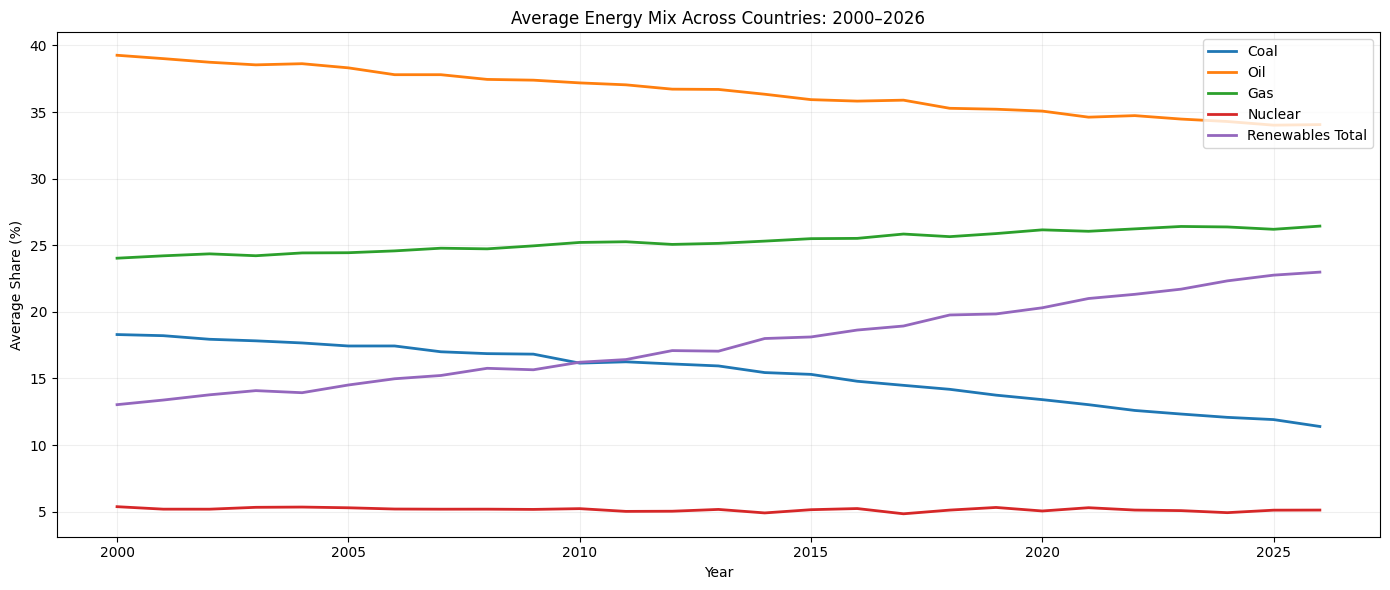

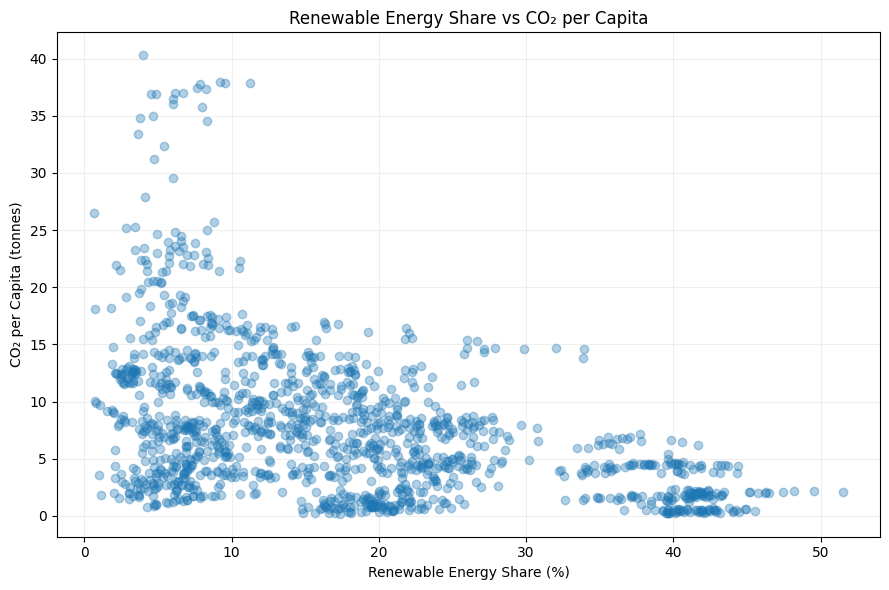

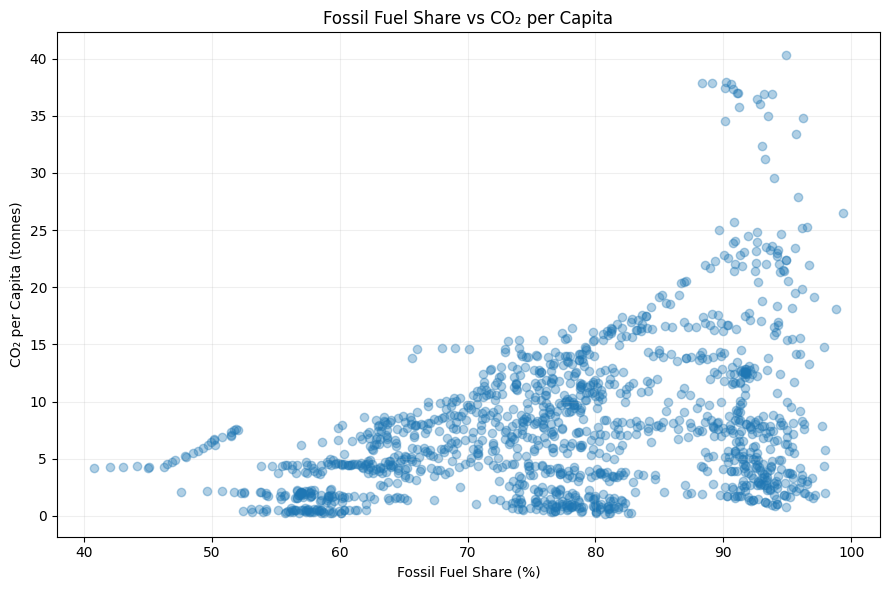

In [8]:
# ============================================================
# CELL 7 — CORE EXPLORATORY DATA ANALYSIS
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. CARBON PRICE TREND BY MARKET
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

for market, g in carbon_clean.groupby("market"):
    plt.plot(g["date"], g["price"], label=market, linewidth=1.5)

plt.title("Carbon Price Evolution by Market")
plt.xlabel("Date")
plt.ylabel("Carbon Price (Local Currency)")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. GLOBAL TEMPERATURE ANOMALY
# ------------------------------------------------------------

global_temp = temp_clean[
    temp_clean["region"] == "Global"
].copy()

plt.figure(figsize=(14, 5))

plt.plot(
    global_temp["year_month"],
    global_temp["temp_anomaly_c"],
    linewidth=1.5
)

# 12-month rolling mean
global_temp["temp_12m_ma"] = (
    global_temp["temp_anomaly_c"]
    .rolling(12)
    .mean()
)

plt.plot(
    global_temp["year_month"],
    global_temp["temp_12m_ma"],
    linewidth=2.5,
    label="12-Month Moving Average"
)

plt.axhline(0, linewidth=1)

plt.title("Global Temperature Anomaly: 2000–2026")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. ATMOSPHERIC CO2 TREND
# Only Global has CO2 ppm — confirmed during audit
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    global_temp["year_month"],
    global_temp["co2_ppm"],
    linewidth=2
)

plt.title("Global Atmospheric CO₂ Concentration")
plt.xlabel("Year")
plt.ylabel("CO₂ (ppm)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. GLOBAL AVERAGE ENERGY TRANSITION
# ------------------------------------------------------------

energy_global = (
    energy_clean
    .groupby("year")[
        [
            "coal_pct",
            "oil_pct",
            "gas_pct",
            "nuclear_pct",
            "renewables_total_pct"
        ]
    ]
    .mean()
)

plt.figure(figsize=(14, 6))

for col in energy_global.columns:
    plt.plot(
        energy_global.index,
        energy_global[col],
        label=col.replace("_pct", "").replace("_", " ").title(),
        linewidth=2
    )

plt.title("Average Energy Mix Across Countries: 2000–2026")
plt.xlabel("Year")
plt.ylabel("Average Share (%)")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. RENEWABLES VS CO2 PER CAPITA
# ------------------------------------------------------------

eda_merged = energy_clean.merge(
    co2_clean[
        [
            "year",
            "iso3",
            "co2_per_capita_t",
            "co2_emissions_mt"
        ]
    ],
    on=["year", "iso3"],
    how="inner"
)

plt.figure(figsize=(9, 6))

plt.scatter(
    eda_merged["renewables_total_pct"],
    eda_merged["co2_per_capita_t"],
    alpha=0.35
)

plt.title("Renewable Energy Share vs CO₂ per Capita")
plt.xlabel("Renewable Energy Share (%)")
plt.ylabel("CO₂ per Capita (tonnes)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. FOSSIL SHARE VS CO2 PER CAPITA
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    eda_merged["fossil_total_pct"],
    eda_merged["co2_per_capita_t"],
    alpha=0.35
)

plt.title("Fossil Fuel Share vs CO₂ per Capita")
plt.xlabel("Fossil Fuel Share (%)")
plt.ylabel("CO₂ per Capita (tonnes)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# CELL 8 — EDA INSIGHT TABLES
# ============================================================

print("=" * 70)
print("1. ENERGY TRANSITION: 2000 VS 2026")
print("=" * 70)

transition_summary = (
    energy_clean[
        energy_clean["year"].isin([2000, 2026])
    ]
    .groupby("year")[
        [
            "coal_pct",
            "oil_pct",
            "gas_pct",
            "renewables_total_pct",
            "fossil_total_pct"
        ]
    ]
    .mean()
    .round(2)
)

display(transition_summary)


print("\n" + "=" * 70)
print("2. CO2 PER CAPITA: 2000 VS 2026")
print("=" * 70)

co2_summary = (
    co2_clean[
        co2_clean["year"].isin([2000, 2026])
    ]
    .groupby("year")["co2_per_capita_t"]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

display(co2_summary)


print("\n" + "=" * 70)
print("3. COUNTRIES WITH BIGGEST RENEWABLE INCREASE")
print("=" * 70)

renewable_change = (
    energy_clean.pivot(
        index=["country", "iso3"],
        columns="year",
        values="renewables_total_pct"
    )
)

renewable_change["change_2000_2026"] = (
    renewable_change[2026] -
    renewable_change[2000]
)

display(
    renewable_change[
        ["change_2000_2026"]
    ]
    .sort_values(
        "change_2000_2026",
        ascending=False
    )
    .head(10)
)


print("\n" + "=" * 70)
print("4. COUNTRIES WITH BIGGEST CO2 PER CAPITA DECLINE")
print("=" * 70)

co2_change = (
    co2_clean.pivot(
        index=["country", "iso3"],
        columns="year",
        values="co2_per_capita_t"
    )
)

co2_change["change_2000_2026"] = (
    co2_change[2026] -
    co2_change[2000]
)

display(
    co2_change[
        ["change_2000_2026"]
    ]
    .sort_values("change_2000_2026")
    .head(10)
)


print("\n" + "=" * 70)
print("5. KEY CORRELATIONS")
print("=" * 70)

print(
    "Renewables vs CO2 per capita:",
    round(
        eda_merged[
            ["renewables_total_pct", "co2_per_capita_t"]
        ].corr().iloc[0, 1],
        3
    )
)

print(
    "Fossil share vs CO2 per capita:",
    round(
        eda_merged[
            ["fossil_total_pct", "co2_per_capita_t"]
        ].corr().iloc[0, 1],
        3
    )
)

1. ENERGY TRANSITION: 2000 VS 2026


,coal_pct,oil_pct,gas_pct,renewables_total_pct,fossil_total_pct
year,,,,,
2000,18.3,39.26,24.03,13.04,81.59
2026,11.4,34.06,26.44,22.98,71.89



2. CO2 PER CAPITA: 2000 VS 2026


,mean,median,min,max
year,,,,
2000,7.40,7.38,0.18,21.49
2026,7.21,5.03,0.48,37.90



3. COUNTRIES WITH BIGGEST RENEWABLE INCREASE


,year,change_2000_2026
country,iso3,
Germany,DEU,28.34
United Kingdom,GBR,25.27
Australia,AUS,21.59
Poland,POL,20.28
Italy,ITA,19.12
Czech Republic,CZE,18.30
Belgium,BEL,18.20
Ukraine,UKR,18.06
Finland,FIN,17.61



4. COUNTRIES WITH BIGGEST CO2 PER CAPITA DECLINE


,year,change_2000_2026
country,iso3,
Finland,FIN,-8.23
Denmark,DNK,-6.81
United States,USA,-6.58
Ukraine,UKR,-6.52
Czech Republic,CZE,-5.99
United Kingdom,GBR,-5.97
Belgium,BEL,-5.86
Germany,DEU,-5.43
Italy,ITA,-4.59



5. KEY CORRELATIONS
Renewables vs CO2 per capita: -0.45
Fossil share vs CO2 per capita: 0.395


In [10]:
# ============================================================
# SAVE CLEAN DATASETS FOR TEAM
# ============================================================

import os

CLEAN_PATH = (
    "/content/drive/MyDrive/"
    "Datathon_2026/Clean_Data"
)

os.makedirs(CLEAN_PATH, exist_ok=True)

# Save all clean datasets
carbon_clean.to_csv(
    f"{CLEAN_PATH}/carbon_prices_clean.csv",
    index=False
)

events_clean.to_csv(
    f"{CLEAN_PATH}/climate_events_clean.csv",
    index=False
)

co2_clean.to_csv(
    f"{CLEAN_PATH}/co2_emissions_clean.csv",
    index=False
)

energy_clean.to_csv(
    f"{CLEAN_PATH}/energy_mix_clean.csv",
    index=False
)

temp_clean.to_csv(
    f"{CLEAN_PATH}/temperature_anomaly_clean.csv",
    index=False
)

print("✅ CLEAN DATASETS SAVED")
print(CLEAN_PATH)

✅ CLEAN DATASETS SAVED
/content/drive/MyDrive/Datathon_2026/Clean_Data


In [11]:
# ============================================================
# SAVE ALL CLEAN DATASETS + CREATE ZIP
# ============================================================

import os
import zipfile

# Folder to save cleaned datasets
CLEAN_PATH = "/content/drive/MyDrive/Datathon_2026/Clean_Data"

os.makedirs(CLEAN_PATH, exist_ok=True)

# ------------------------------------------------------------
# SAVE CLEAN DATASETS
# ------------------------------------------------------------

carbon_clean.to_csv(
    f"{CLEAN_PATH}/carbon_prices_clean.csv",
    index=False
)

events_clean.to_csv(
    f"{CLEAN_PATH}/climate_events_clean.csv",
    index=False
)

co2_clean.to_csv(
    f"{CLEAN_PATH}/co2_emissions_clean.csv",
    index=False
)

energy_clean.to_csv(
    f"{CLEAN_PATH}/energy_mix_clean.csv",
    index=False
)

temp_clean.to_csv(
    f"{CLEAN_PATH}/temperature_anomaly_clean.csv",
    index=False
)

# ------------------------------------------------------------
# CREATE CLEANING LOG
# ------------------------------------------------------------

cleaning_log = """
CODEFEST DATATHON 2026 - CLEAN DATASET NOTES

1. No duplicate rows were identified.
2. No valid carbon-price outliers were removed.
3. Energy shares were retained because totals were approximately 100%.
4. co2_ppm missing values were not imputed because they are structurally
   available only for the Global temperature series.
5. CO2 and Energy Mix datasets retain complete 2000-2026 coverage.
6. Temporal datasets were sorted chronologically.
7. No feature engineering, scaling, encoding or train/test splitting
   has been applied yet.
"""

with open(
    f"{CLEAN_PATH}/CLEANING_LOG.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(cleaning_log)

# ------------------------------------------------------------
# CREATE ZIP
# ------------------------------------------------------------

ZIP_PATH = "/content/drive/MyDrive/Datathon_2026/Datathon_2026_Clean_Data.zip"

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for filename in os.listdir(CLEAN_PATH):

        file_path = os.path.join(
            CLEAN_PATH,
            filename
        )

        zipf.write(
            file_path,
            arcname=filename
        )

print("✅ CLEAN DATASETS SAVED")
print("✅ ZIP CREATED")
print("\nZIP location:")
print(ZIP_PATH)

✅ CLEAN DATASETS SAVED
✅ ZIP CREATED

ZIP location:
/content/drive/MyDrive/Datathon_2026/Datathon_2026_Clean_Data.zip


In [12]:
# ============================================================
# PIPELINE A — CARBON PRICE FORECASTING
# FEATURE ENGINEERING
# ============================================================

import pandas as pd
import numpy as np

carbon_A = carbon_clean.copy()

carbon_A = (
    carbon_A
    .sort_values(["market", "date"])
    .reset_index(drop=True)
)

# Ensure datetime
carbon_A["date"] = pd.to_datetime(carbon_A["date"])

# ------------------------------------------------------------
# LOG PRICE + RETURN
# ------------------------------------------------------------

carbon_A["log_price"] = np.log(carbon_A["price"])

carbon_A["log_return"] = (
    carbon_A.groupby("market")["log_price"].diff()
)

# ------------------------------------------------------------
# CALENDAR FEATURES
# ------------------------------------------------------------

carbon_A["day_of_week"] = carbon_A["date"].dt.dayofweek
carbon_A["month"] = carbon_A["date"].dt.month
carbon_A["quarter"] = carbon_A["date"].dt.quarter

# Cyclical encoding
carbon_A["dow_sin"] = np.sin(
    2 * np.pi * carbon_A["day_of_week"] / 7
)

carbon_A["dow_cos"] = np.cos(
    2 * np.pi * carbon_A["day_of_week"] / 7
)

carbon_A["month_sin"] = np.sin(
    2 * np.pi * carbon_A["month"] / 12
)

carbon_A["month_cos"] = np.cos(
    2 * np.pi * carbon_A["month"] / 12
)

# ------------------------------------------------------------
# PRICE LAGS
# ------------------------------------------------------------

for lag in [1, 2, 3, 5, 10, 20, 30]:

    carbon_A[f"price_lag_{lag}"] = (
        carbon_A
        .groupby("market")["price"]
        .shift(lag)
    )

# ------------------------------------------------------------
# RETURN LAGS
# ------------------------------------------------------------

for lag in [1, 2, 3, 5, 10, 20]:

    carbon_A[f"return_lag_{lag}"] = (
        carbon_A
        .groupby("market")["log_return"]
        .shift(lag)
    )

# ------------------------------------------------------------
# ROLLING FEATURES
# shift(1) prevents current-day leakage
# ------------------------------------------------------------

for window in [5, 10, 20, 30]:

    carbon_A[f"price_mean_{window}"] = (
        carbon_A
        .groupby("market")["price"]
        .transform(
            lambda x:
            x.shift(1).rolling(window).mean()
        )
    )

    carbon_A[f"price_std_{window}"] = (
        carbon_A
        .groupby("market")["price"]
        .transform(
            lambda x:
            x.shift(1).rolling(window).std()
        )
    )

    carbon_A[f"volatility_{window}"] = (
        carbon_A
        .groupby("market")["log_return"]
        .transform(
            lambda x:
            x.shift(1).rolling(window).std()
        )
    )

# ------------------------------------------------------------
# MOMENTUM
# ------------------------------------------------------------

carbon_A["momentum_5"] = (
    carbon_A["price_lag_1"] /
    carbon_A["price_lag_5"] - 1
)

carbon_A["momentum_10"] = (
    carbon_A["price_lag_1"] /
    carbon_A["price_lag_10"] - 1
)

carbon_A["momentum_20"] = (
    carbon_A["price_lag_1"] /
    carbon_A["price_lag_20"] - 1
)

# ------------------------------------------------------------
# TARGET
# ------------------------------------------------------------

carbon_A["target_price"] = carbon_A["price"]

# Remove rows unavailable due to lag/rolling construction
carbon_ready = (
    carbon_A
    .dropna()
    .reset_index(drop=True)
)

print("Original rows :", len(carbon_clean))
print("Ready rows    :", len(carbon_ready))
print("Columns       :", carbon_ready.shape[1])

display(carbon_ready.head())

Original rows : 15866
Ready rows    : 15711
Columns       : 43


,date,year,market,currency,price,log_price,log_return,day_of_week,month,quarter,...,price_mean_20,price_std_20,volatility_20,price_mean_30,price_std_30,volatility_30,momentum_5,momentum_10,momentum_20,target_price
0,2014-01-01,2014,California,USD,10.16,2.318458,0.017875,2,1,1,...,10.1645,0.280366,0.038276,10.082667,0.303178,0.037207,0.014228,-0.020608,-0.019646,10.16
1,2014-01-02,2014,California,USD,10.39,2.340844,0.022385,3,1,1,...,10.1635,0.280343,0.037557,10.081667,0.302861,0.037291,0.010945,0.014985,-0.021195,10.39
2,2014-01-03,2014,California,USD,10.48,2.349469,0.008625,4,1,1,...,10.1640,0.280758,0.037643,10.092333,0.308027,0.037442,0.046324,0.019627,0.025666,10.48
3,2014-01-06,2014,California,USD,10.21,2.323368,-0.026101,0,1,1,...,10.1815,0.289305,0.037237,10.122667,0.299505,0.036148,0.002871,0.013540,0.069388,10.21
4,2014-01-07,2014,California,USD,10.26,2.328253,0.004885,1,1,1,...,10.2020,0.275023,0.036923,10.119667,0.298115,0.033960,0.023046,0.026131,0.034448,10.26


In [13]:
# ============================================================
# TIME-BASED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

train_parts = []
val_parts = []
test_parts = []

for market, df_market in carbon_ready.groupby("market"):

    df_market = (
        df_market
        .sort_values("date")
        .reset_index(drop=True)
    )

    # Last 30 = test
    test_market = df_market.iloc[-30:].copy()

    # Previous 30 = validation
    val_market = df_market.iloc[-60:-30].copy()

    # All earlier observations = train
    train_market = df_market.iloc[:-60].copy()

    train_parts.append(train_market)
    val_parts.append(val_market)
    test_parts.append(test_market)


carbon_train = pd.concat(
    train_parts
).reset_index(drop=True)

carbon_val = pd.concat(
    val_parts
).reset_index(drop=True)

carbon_test = pd.concat(
    test_parts
).reset_index(drop=True)


print("=" * 60)
print("CARBON FORECAST SPLIT")
print("=" * 60)

print("Train      :", carbon_train.shape)
print("Validation :", carbon_val.shape)
print("Test       :", carbon_test.shape)

print("\nValidation per market:")
print(carbon_val.groupby("market").size())

print("\nTest per market:")
print(carbon_test.groupby("market").size())

CARBON FORECAST SPLIT
Train      : (15411, 43)
Validation : (150, 43)
Test       : (150, 43)

Validation per market:
market
California    30
China_ETS     30
EU_ETS        30
RGGI          30
UK_ETS        30
dtype: int64

Test per market:
market
California    30
China_ETS     30
EU_ETS        30
RGGI          30
UK_ETS        30
dtype: int64


In [14]:
# ============================================================
# PREPARE FEATURES
# ============================================================

DROP_COLUMNS = [
    "date",
    "price",
    "target_price",
    "currency",
    "log_price",
    "log_return"
]

X_train = carbon_train.drop(
    columns=DROP_COLUMNS
)

X_val = carbon_val.drop(
    columns=DROP_COLUMNS
)

X_test = carbon_test.drop(
    columns=DROP_COLUMNS
)

y_train = carbon_train["target_price"]
y_val = carbon_val["target_price"]
y_test = carbon_test["target_price"]

# One-hot encode market
X_train = pd.get_dummies(
    X_train,
    columns=["market"],
    drop_first=False
)

X_val = pd.get_dummies(
    X_val,
    columns=["market"],
    drop_first=False
)

X_test = pd.get_dummies(
    X_test,
    columns=["market"],
    drop_first=False
)

# Ensure same columns everywhere
X_val = X_val.reindex(
    columns=X_train.columns,
    fill_value=0
)

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\nFeatures:")
print(X_train.columns.tolist())

X_train: (15411, 41)
X_val  : (150, 41)
X_test : (150, 41)

Features:
['year', 'day_of_week', 'month', 'quarter', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'price_lag_1', 'price_lag_2', 'price_lag_3', 'price_lag_5', 'price_lag_10', 'price_lag_20', 'price_lag_30', 'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5', 'return_lag_10', 'return_lag_20', 'price_mean_5', 'price_std_5', 'volatility_5', 'price_mean_10', 'price_std_10', 'volatility_10', 'price_mean_20', 'price_std_20', 'volatility_20', 'price_mean_30', 'price_std_30', 'volatility_30', 'momentum_5', 'momentum_10', 'momentum_20', 'market_California', 'market_China_ETS', 'market_EU_ETS', 'market_RGGI', 'market_UK_ETS']


In [15]:
# ============================================================
# NAIVE BASELINE
# ============================================================

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

naive_val_pred = carbon_val["price_lag_1"]

naive_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        naive_val_pred
    )
)

naive_mape = (
    mean_absolute_percentage_error(
        y_val,
        naive_val_pred
    ) * 100
)

print("=" * 50)
print("NAIVE BASELINE — VALIDATION")
print("=" * 50)

print(f"RMSE : {naive_rmse:.4f}")
print(f"MAPE : {naive_mape:.2f}%")

NAIVE BASELINE — VALIDATION
RMSE : 2.9351
MAPE : 3.06%


In [16]:
# ============================================================
# EXTRA TREES REGRESSOR
# ============================================================

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

extra_model = ExtraTreesRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features=0.8,
    n_jobs=-1,
    random_state=42
)

extra_model.fit(
    X_train,
    y_train
)

# Validation prediction
val_pred = extra_model.predict(X_val)

val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        val_pred
    )
)

val_mae = mean_absolute_error(
    y_val,
    val_pred
)

val_mape = (
    mean_absolute_percentage_error(
        y_val,
        val_pred
    ) * 100
)

val_r2 = r2_score(
    y_val,
    val_pred
)

print("=" * 55)
print("EXTRA TREES — VALIDATION RESULTS")
print("=" * 55)

print(f"RMSE : {val_rmse:.4f}")
print(f"MAE  : {val_mae:.4f}")
print(f"MAPE : {val_mape:.2f}%")
print(f"R²   : {val_r2:.4f}")

EXTRA TREES — VALIDATION RESULTS
RMSE : 2.6266
MAE  : 1.7076
MAPE : 2.65%
R²   : 0.9941


In [17]:
# ============================================================
# BASELINE VS EXTRA TREES
# ============================================================

improvement = (
    (naive_rmse - val_rmse) /
    naive_rmse * 100
)

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(f"Naive RMSE       : {naive_rmse:.4f}")
print(f"Extra Trees RMSE : {val_rmse:.4f}")

print(
    f"\nRMSE improvement over naive: "
    f"{improvement:.2f}%"
)

if val_rmse < naive_rmse:
    print("\n✅ Extra Trees beats the naive baseline.")
else:
    print("\n⚠️ Naive baseline currently performs better.")

MODEL COMPARISON
Naive RMSE       : 2.9351
Extra Trees RMSE : 2.6266

RMSE improvement over naive: 10.51%

✅ Extra Trees beats the naive baseline.


In [18]:
# ============================================================
# EXTRA TREES — VALIDATION PERFORMANCE BY MARKET
# ============================================================

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

val_results = carbon_val[
    ["date", "market", "target_price", "price_lag_1"]
].copy()

val_results["extra_trees_pred"] = val_pred

market_metrics = []

for market, g in val_results.groupby("market"):

    rmse_naive = np.sqrt(
        mean_squared_error(
            g["target_price"],
            g["price_lag_1"]
        )
    )

    rmse_et = np.sqrt(
        mean_squared_error(
            g["target_price"],
            g["extra_trees_pred"]
        )
    )

    mape_et = (
        mean_absolute_percentage_error(
            g["target_price"],
            g["extra_trees_pred"]
        ) * 100
    )

    mae_et = mean_absolute_error(
        g["target_price"],
        g["extra_trees_pred"]
    )

    improvement = (
        (rmse_naive - rmse_et) /
        rmse_naive * 100
    )

    market_metrics.append({
        "Market": market,
        "Naive_RMSE": rmse_naive,
        "ExtraTrees_RMSE": rmse_et,
        "ExtraTrees_MAE": mae_et,
        "ExtraTrees_MAPE_%": mape_et,
        "RMSE_Improvement_%": improvement
    })

market_metrics = pd.DataFrame(market_metrics)

display(
    market_metrics.round(3)
)

,Market,Naive_RMSE,ExtraTrees_RMSE,ExtraTrees_MAE,ExtraTrees_MAPE_%,RMSE_Improvement_%
0,California,1.274,1.013,0.806,2.506,20.495
1,China_ETS,5.103,4.890,3.963,3.434,4.190
2,EU_ETS,3.537,2.641,2.025,2.464,25.321
3,RGGI,0.540,0.486,0.406,2.006,10.167
4,UK_ETS,1.614,1.533,1.338,2.815,5.015


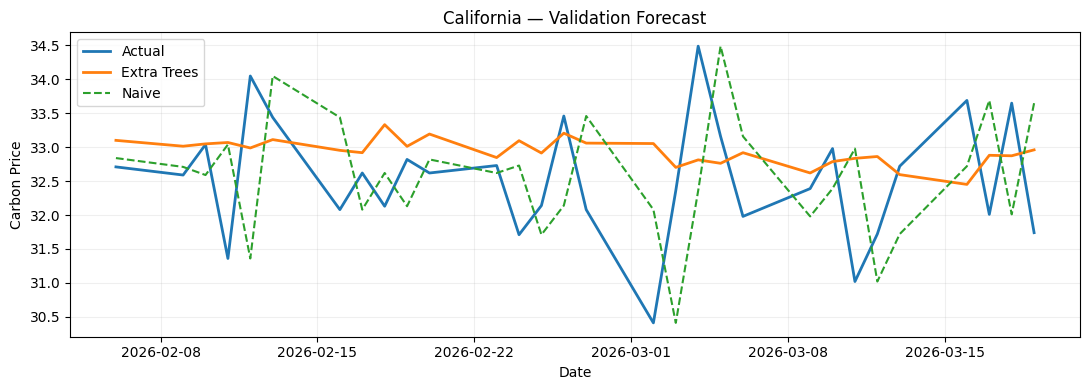

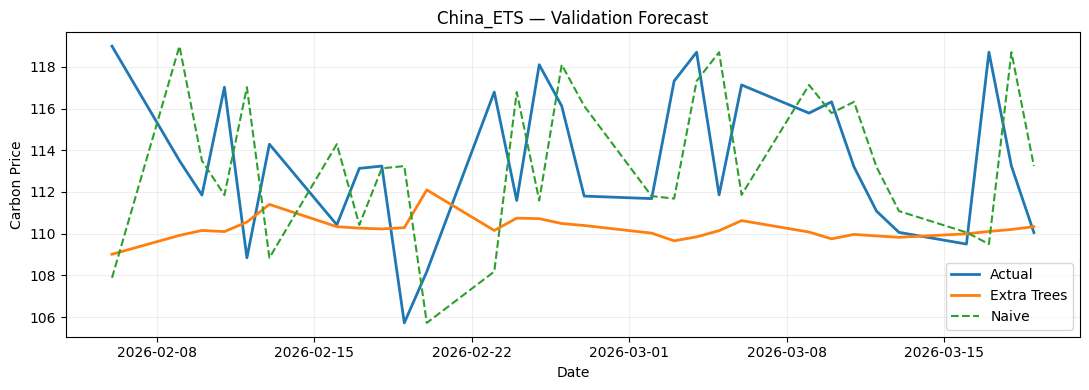

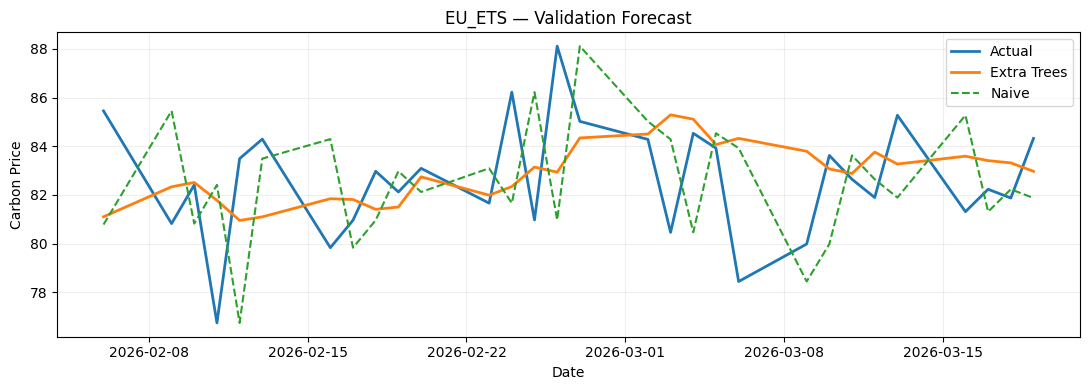

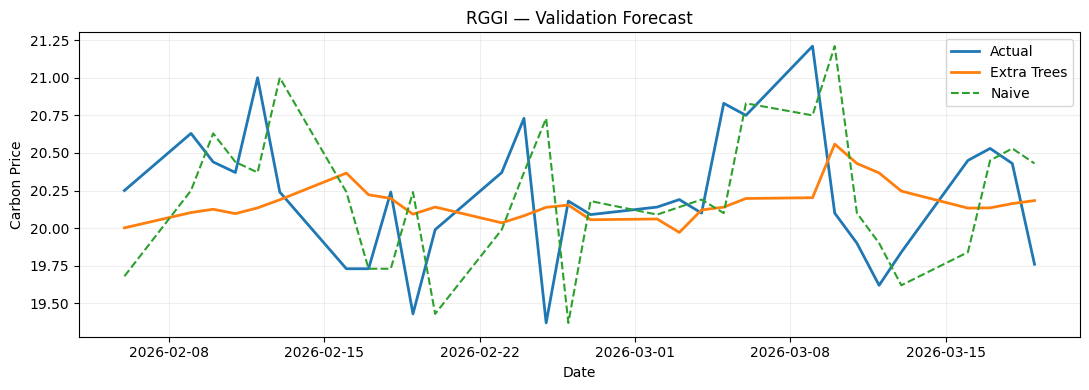

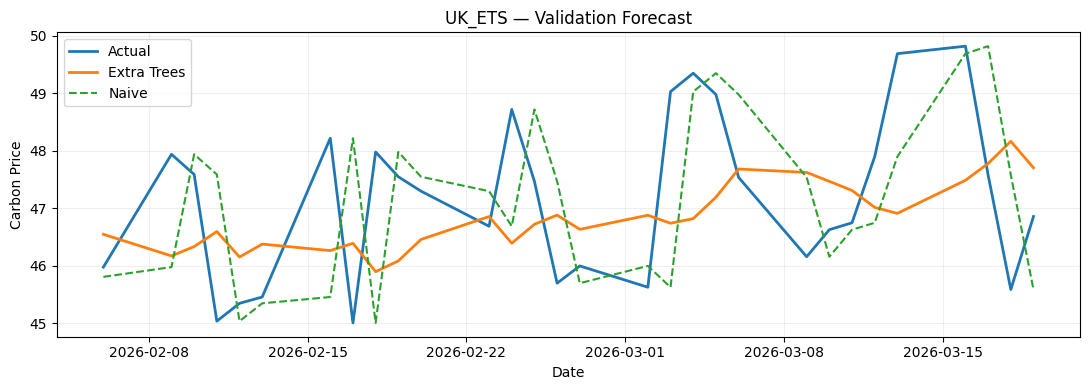

In [19]:
# ============================================================
# VALIDATION — ACTUAL VS PREDICTED
# ============================================================

import matplotlib.pyplot as plt

for market in val_results["market"].unique():

    g = (
        val_results[
            val_results["market"] == market
        ]
        .sort_values("date")
    )

    plt.figure(figsize=(11, 4))

    plt.plot(
        g["date"],
        g["target_price"],
        label="Actual",
        linewidth=2
    )

    plt.plot(
        g["date"],
        g["extra_trees_pred"],
        label="Extra Trees",
        linewidth=2
    )

    plt.plot(
        g["date"],
        g["price_lag_1"],
        label="Naive",
        linestyle="--"
    )

    plt.title(f"{market} — Validation Forecast")
    plt.xlabel("Date")
    plt.ylabel("Carbon Price")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

In [21]:
# ============================================================
# A7 — ARIMA VALIDATION (INDEX-SAFE VERSION)
# ============================================================

from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

# Fresh prediction container
arima_predictions = pd.Series(
    index=carbon_val.index,
    dtype=float
)

for market in carbon_val["market"].unique():

    print(f"Running ARIMA: {market}")

    # --------------------------------------------------------
    # Training history
    # --------------------------------------------------------
    tr = (
        carbon_train[
            carbon_train["market"] == market
        ]
        .sort_values("date")
        .copy()
    )

    # Validation
    va = (
        carbon_val[
            carbon_val["market"] == market
        ]
        .sort_values("date")
        .copy()
    )

    # IMPORTANT:
    # convert to NumPy so statsmodels does not use
    # the original pandas row index
    history = np.log(
        tr["target_price"].to_numpy(dtype=float)
    )

    # Initial ARIMA model
    model = ARIMA(
        history,
        order=(1, 1, 1)
    )

    fitted = model.fit()

    # --------------------------------------------------------
    # Rolling one-step forecasts
    # --------------------------------------------------------
    for idx, row in va.iterrows():

        # Forecast next log price
        pred_log = float(
            np.asarray(
                fitted.forecast(steps=1)
            ).ravel()[0]
        )

        # Back-transform to price
        pred_price = np.exp(pred_log)

        arima_predictions.loc[idx] = pred_price

        # Reveal actual validation observation
        actual_log = np.log(
            float(row["target_price"])
        )

        # Update model state WITHOUT refitting parameters
        fitted = fitted.append(
            np.array([actual_log]),
            refit=False
        )

    print(f"✅ {market} complete")

print("\n✅ ALL ARIMA VALIDATION FORECASTS COMPLETE")

Running ARIMA: California
✅ California complete
Running ARIMA: China_ETS
✅ China_ETS complete
Running ARIMA: EU_ETS
✅ EU_ETS complete
Running ARIMA: RGGI
✅ RGGI complete
Running ARIMA: UK_ETS
✅ UK_ETS complete

✅ ALL ARIMA VALIDATION FORECASTS COMPLETE


In [22]:
# ============================================================
# A8 — CHECK ARIMA PREDICTIONS
# ============================================================

print("Missing ARIMA predictions:",
      arima_predictions.isna().sum())

print("Total ARIMA predictions:",
      arima_predictions.notna().sum())

Missing ARIMA predictions: 0
Total ARIMA predictions: 150


In [23]:
# ============================================================
# A9 — ARIMA VALIDATION METRICS
# ============================================================

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

arima_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        arima_predictions
    )
)

arima_mae = mean_absolute_error(
    y_val,
    arima_predictions
)

arima_mape = (
    mean_absolute_percentage_error(
        y_val,
        arima_predictions
    ) * 100
)

print("=" * 55)
print("ARIMA — VALIDATION RESULTS")
print("=" * 55)

print(f"RMSE : {arima_rmse:.4f}")
print(f"MAE  : {arima_mae:.4f}")
print(f"MAPE : {arima_mape:.2f}%")

ARIMA — VALIDATION RESULTS
RMSE : 2.3420
MAE  : 1.6121
MAPE : 2.54%


In [24]:
# ============================================================
# A10 — FINAL VALIDATION COMPARISON
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "Naive Lag-1",
        "ARIMA (1,1,1)",
        "Extra Trees"
    ],

    "RMSE": [
        naive_rmse,
        arima_rmse,
        val_rmse
    ],

    "MAPE_%": [
        naive_mape,
        arima_mape,
        val_mape
    ]
})

comparison = (
    comparison
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(comparison.round(4))

,Model,RMSE,MAPE_%
0,"ARIMA (1,1,1)",2.3420,2.5380
1,Extra Trees,2.6266,2.6452
2,Naive Lag-1,2.9351,3.0604


In [25]:
# ============================================================
# A11 — TRUE 30-STEP ARIMA TEST
# ============================================================

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

import numpy as np
import pandas as pd

arima_test_predictions = pd.Series(
    index=carbon_test.index,
    dtype=float
)

for market in carbon_test["market"].unique():

    print(f"Forecasting 30 steps: {market}")

    # All information available BEFORE test starts
    history_df = pd.concat([
        carbon_train[carbon_train["market"] == market],
        carbon_val[carbon_val["market"] == market]
    ]).sort_values("date")

    test_market = (
        carbon_test[
            carbon_test["market"] == market
        ]
        .sort_values("date")
    )

    # Log-price history
    history_log = np.log(
        history_df["target_price"].to_numpy(dtype=float)
    )

    # Fit ARIMA
    fitted = ARIMA(
        history_log,
        order=(1, 1, 1)
    ).fit()

    # TRUE 30-step forecast
    forecast_log = np.asarray(
        fitted.forecast(
            steps=len(test_market)
        )
    )

    forecast_price = np.exp(forecast_log)

    arima_test_predictions.loc[
        test_market.index
    ] = forecast_price

    print(f"✅ {market}")

print("\n✅ TRUE 30-STEP TEST FORECAST COMPLETE")

Forecasting 30 steps: California
✅ California
Forecasting 30 steps: China_ETS
✅ China_ETS
Forecasting 30 steps: EU_ETS
✅ EU_ETS
Forecasting 30 steps: RGGI
✅ RGGI
Forecasting 30 steps: UK_ETS
✅ UK_ETS

✅ TRUE 30-STEP TEST FORECAST COMPLETE


In [26]:
# ============================================================
# A12 — TRUE TEST RESULTS
# ============================================================

y_test = carbon_test["target_price"]

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        arima_test_predictions
    )
)

test_mae = mean_absolute_error(
    y_test,
    arima_test_predictions
)

test_mape = (
    mean_absolute_percentage_error(
        y_test,
        arima_test_predictions
    ) * 100
)

print("=" * 55)
print("ARIMA — TRUE 30-DAY TEST RESULTS")
print("=" * 55)

print(f"RMSE : {test_rmse:.4f}")
print(f"MAE  : {test_mae:.4f}")
print(f"MAPE : {test_mape:.2f}%")

ARIMA — TRUE 30-DAY TEST RESULTS
RMSE : 1.9921
MAE  : 1.4771
MAPE : 2.60%


In [27]:
# ============================================================
# A13 — TRUE 30-DAY NAIVE BASELINE
# ============================================================

naive_test_predictions = pd.Series(
    index=carbon_test.index,
    dtype=float
)

for market in carbon_test["market"].unique():

    history = pd.concat([
        carbon_train[
            carbon_train["market"] == market
        ],
        carbon_val[
            carbon_val["market"] == market
        ]
    ]).sort_values("date")

    test_market = (
        carbon_test[
            carbon_test["market"] == market
        ]
        .sort_values("date")
    )

    last_known_price = history["target_price"].iloc[-1]

    naive_test_predictions.loc[
        test_market.index
    ] = last_known_price


naive_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        naive_test_predictions
    )
)

naive_test_mape = (
    mean_absolute_percentage_error(
        y_test,
        naive_test_predictions
    ) * 100
)

print("=" * 55)
print("TRUE 30-DAY NAIVE TEST")
print("=" * 55)

print(f"RMSE : {naive_test_rmse:.4f}")
print(f"MAPE : {naive_test_mape:.2f}%")

TRUE 30-DAY NAIVE TEST
RMSE : 2.7031
MAPE : 2.93%


In [28]:
test_comparison = pd.DataFrame({
    "Model": [
        "Naive 30-Step",
        "ARIMA (1,1,1) 30-Step"
    ],
    "RMSE": [
        naive_test_rmse,
        test_rmse
    ],
    "MAPE_%": [
        naive_test_mape,
        test_mape
    ]
})

display(
    test_comparison
    .sort_values("RMSE")
    .round(4)
)

,Model,RMSE,MAPE_%
1,"ARIMA (1,1,1) 30-Step",1.9921,2.5967
0,Naive 30-Step,2.7031,2.9263


In [29]:
# ============================================================
# A14 — TRUE 30-DAY PERFORMANCE BY MARKET
# ============================================================

market_test_results = []

test_results = carbon_test[
    ["date", "market", "target_price"]
].copy()

test_results["ARIMA_pred"] = arima_test_predictions
test_results["Naive_pred"] = naive_test_predictions

for market, g in test_results.groupby("market"):

    actual = g["target_price"]
    arima_p = g["ARIMA_pred"]
    naive_p = g["Naive_pred"]

    arima_rmse_m = np.sqrt(
        mean_squared_error(actual, arima_p)
    )

    naive_rmse_m = np.sqrt(
        mean_squared_error(actual, naive_p)
    )

    arima_mape_m = (
        mean_absolute_percentage_error(
            actual, arima_p
        ) * 100
    )

    naive_mape_m = (
        mean_absolute_percentage_error(
            actual, naive_p
        ) * 100
    )

    improvement = (
        (naive_rmse_m - arima_rmse_m)
        / naive_rmse_m * 100
    )

    market_test_results.append({
        "Market": market,
        "Naive_RMSE": naive_rmse_m,
        "ARIMA_RMSE": arima_rmse_m,
        "Naive_MAPE_%": naive_mape_m,
        "ARIMA_MAPE_%": arima_mape_m,
        "RMSE_Improvement_%": improvement
    })

market_test_results = pd.DataFrame(
    market_test_results
)

display(
    market_test_results.round(3)
)

,Market,Naive_RMSE,ARIMA_RMSE,Naive_MAPE_%,ARIMA_MAPE_%,RMSE_Improvement_%
0,California,0.887,1.136,2.290,2.896,-28.010
1,China_ETS,4.912,3.022,3.560,2.194,38.477
2,EU_ETS,2.162,2.113,1.985,2.003,2.240
3,RGGI,0.607,0.522,2.266,2.167,13.996
4,UK_ETS,2.564,2.163,4.529,3.723,15.636


In [30]:
# ============================================================
# A15 — FINAL 30-TRADING-DAY FORECAST
# Retrain on ALL available data
# ============================================================

from statsmodels.tsa.arima.model import ARIMA
import pandas as pd
import numpy as np

future_forecasts = []

for market, g in carbon_clean.groupby("market"):

    print(f"Final forecasting: {market}")

    g = (
        g.sort_values("date")
        .reset_index(drop=True)
    )

    # Full historical price series
    log_prices = np.log(
        g["price"].to_numpy(dtype=float)
    )

    # Fit final selected model
    final_model = ARIMA(
        log_prices,
        order=(1, 1, 1)
    ).fit()

    # 30-step forecast with confidence interval
    forecast_result = final_model.get_forecast(
        steps=30
    )

    mean_log = np.asarray(
        forecast_result.predicted_mean
    )

    conf_log = np.asarray(
        forecast_result.conf_int(alpha=0.05)
    )

    # Convert back to original price scale
    forecast_price = np.exp(mean_log)
    lower_95 = np.exp(conf_log[:, 0])
    upper_95 = np.exp(conf_log[:, 1])

    last_date = pd.to_datetime(
        g["date"].max()
    )

    # Approximate future business-day dates
    # Weekends excluded; market-specific holidays are not modelled
    future_dates = pd.bdate_range(
        start=last_date + pd.offsets.BDay(1),
        periods=30
    )

    currency = g["currency"].iloc[-1]

    market_forecast = pd.DataFrame({
        "market": market,
        "currency": currency,
        "forecast_step": np.arange(1, 31),
        "approx_trading_date": future_dates,
        "forecast_price": forecast_price,
        "lower_95": lower_95,
        "upper_95": upper_95
    })

    future_forecasts.append(
        market_forecast
    )

final_30day_forecast = pd.concat(
    future_forecasts,
    ignore_index=True
)

print("\n✅ FINAL 30-DAY FORECAST COMPLETE")

display(
    final_30day_forecast.head(15)
)

Final forecasting: California
Final forecasting: China_ETS
Final forecasting: EU_ETS
Final forecasting: RGGI
Final forecasting: UK_ETS

✅ FINAL 30-DAY FORECAST COMPLETE


,market,currency,forecast_step,approx_trading_date,forecast_price,lower_95,upper_95
0,California,USD,1,2026-05-01,31.781279,30.201792,33.443369
1,California,USD,2,2026-05-04,31.801329,30.215521,33.470366
2,California,USD,3,2026-05-05,31.800563,30.204096,33.481412
3,California,USD,4,2026-05-06,31.800592,30.193743,33.492955
4,California,USD,5,2026-05-07,31.800591,30.183423,33.504403
5,California,USD,6,2026-05-08,31.800591,30.173176,33.515782
6,California,USD,7,2026-05-11,31.800591,30.162998,33.527092
7,California,USD,8,2026-05-12,31.800591,30.152887,33.538333
8,California,USD,9,2026-05-13,31.800591,30.142844,33.549508
9,California,USD,10,2026-05-14,31.800591,30.132866,33.560618


In [31]:
# ============================================================
# A15 — FINAL 30-TRADING-DAY FORECAST
# Retrain on ALL available data
# ============================================================

from statsmodels.tsa.arima.model import ARIMA
import pandas as pd
import numpy as np

future_forecasts = []

for market, g in carbon_clean.groupby("market"):

    print(f"Final forecasting: {market}")

    g = (
        g.sort_values("date")
        .reset_index(drop=True)
    )

    # Full historical price series
    log_prices = np.log(
        g["price"].to_numpy(dtype=float)
    )

    # Fit final selected model
    final_model = ARIMA(
        log_prices,
        order=(1, 1, 1)
    ).fit()

    # 30-step forecast with confidence interval
    forecast_result = final_model.get_forecast(
        steps=30
    )

    mean_log = np.asarray(
        forecast_result.predicted_mean
    )

    conf_log = np.asarray(
        forecast_result.conf_int(alpha=0.05)
    )

    # Convert back to original price scale
    forecast_price = np.exp(mean_log)
    lower_95 = np.exp(conf_log[:, 0])
    upper_95 = np.exp(conf_log[:, 1])

    last_date = pd.to_datetime(
        g["date"].max()
    )

    # Approximate future business-day dates
    # Weekends excluded; market-specific holidays are not modelled
    future_dates = pd.bdate_range(
        start=last_date + pd.offsets.BDay(1),
        periods=30
    )

    currency = g["currency"].iloc[-1]

    market_forecast = pd.DataFrame({
        "market": market,
        "currency": currency,
        "forecast_step": np.arange(1, 31),
        "approx_trading_date": future_dates,
        "forecast_price": forecast_price,
        "lower_95": lower_95,
        "upper_95": upper_95
    })

    future_forecasts.append(
        market_forecast
    )

final_30day_forecast = pd.concat(
    future_forecasts,
    ignore_index=True
)

print("\n✅ FINAL 30-DAY FORECAST COMPLETE")

display(
    final_30day_forecast.head(15)
)

Final forecasting: California
Final forecasting: China_ETS
Final forecasting: EU_ETS
Final forecasting: RGGI
Final forecasting: UK_ETS

✅ FINAL 30-DAY FORECAST COMPLETE


,market,currency,forecast_step,approx_trading_date,forecast_price,lower_95,upper_95
0,California,USD,1,2026-05-01,31.781279,30.201792,33.443369
1,California,USD,2,2026-05-04,31.801329,30.215521,33.470366
2,California,USD,3,2026-05-05,31.800563,30.204096,33.481412
3,California,USD,4,2026-05-06,31.800592,30.193743,33.492955
4,California,USD,5,2026-05-07,31.800591,30.183423,33.504403
5,California,USD,6,2026-05-08,31.800591,30.173176,33.515782
6,California,USD,7,2026-05-11,31.800591,30.162998,33.527092
7,California,USD,8,2026-05-12,31.800591,30.152887,33.538333
8,California,USD,9,2026-05-13,31.800591,30.142844,33.549508
9,California,USD,10,2026-05-14,31.800591,30.132866,33.560618


In [32]:
FORECAST_PATH = (
    "/content/drive/MyDrive/"
    "Datathon_2026/Results"
)

import os
os.makedirs(
    FORECAST_PATH,
    exist_ok=True
)

final_30day_forecast.to_csv(
    f"{FORECAST_PATH}/carbon_price_30day_forecast.csv",
    index=False
)

market_test_results.to_csv(
    f"{FORECAST_PATH}/carbon_model_test_metrics.csv",
    index=False
)

print("✅ Forecast and metrics saved")

✅ Forecast and metrics saved


In [33]:
# ============================================================
# MODEL 4 — RIDGE REGRESSION
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_val)

ridge_rmse = np.sqrt(mean_squared_error(y_val, ridge_pred))
ridge_mae = mean_absolute_error(y_val, ridge_pred)
ridge_mape = mean_absolute_percentage_error(y_val, ridge_pred) * 100
ridge_r2 = r2_score(y_val, ridge_pred)

print("=" * 55)
print("RIDGE — VALIDATION RESULTS")
print("=" * 55)
print(f"RMSE : {ridge_rmse:.4f}")
print(f"MAE  : {ridge_mae:.4f}")
print(f"MAPE : {ridge_mape:.2f}%")
print(f"R²   : {ridge_r2:.4f}")

RIDGE — VALIDATION RESULTS
RMSE : 2.2297
MAE  : 1.5465
MAPE : 2.49%
R²   : 0.9958


In [34]:
# ============================================================
# MODEL 5 — RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features=0.8,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_val)

rf_rmse = np.sqrt(mean_squared_error(y_val, rf_pred))
rf_mae = mean_absolute_error(y_val, rf_pred)
rf_mape = mean_absolute_percentage_error(y_val, rf_pred) * 100
rf_r2 = r2_score(y_val, rf_pred)

print("=" * 55)
print("RANDOM FOREST — VALIDATION RESULTS")
print("=" * 55)
print(f"RMSE : {rf_rmse:.4f}")
print(f"MAE  : {rf_mae:.4f}")
print(f"MAPE : {rf_mape:.2f}%")
print(f"R²   : {rf_r2:.4f}")

RANDOM FOREST — VALIDATION RESULTS
RMSE : 2.6063
MAE  : 1.6987
MAPE : 2.64%
R²   : 0.9942


In [35]:
# ============================================================
# MODEL 6 — GRADIENT BOOSTING
# ============================================================

from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=4,
    min_samples_leaf=2,
    subsample=0.9,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_val)

gb_rmse = np.sqrt(mean_squared_error(y_val, gb_pred))
gb_mae = mean_absolute_error(y_val, gb_pred)
gb_mape = mean_absolute_percentage_error(y_val, gb_pred) * 100
gb_r2 = r2_score(y_val, gb_pred)

print("=" * 55)
print("GRADIENT BOOSTING — VALIDATION RESULTS")
print("=" * 55)
print(f"RMSE : {gb_rmse:.4f}")
print(f"MAE  : {gb_mae:.4f}")
print(f"MAPE : {gb_mape:.2f}%")
print(f"R²   : {gb_r2:.4f}")

GRADIENT BOOSTING — VALIDATION RESULTS
RMSE : 2.8006
MAE  : 1.8218
MAPE : 2.78%
R²   : 0.9933


In [36]:
# ============================================================
# ALL 6 APPROACHES — VALIDATION COMPARISON
# ============================================================

all_models = pd.DataFrame({
    "Model": [
        "Naive Lag-1",
        "ARIMA (1,1,1)",
        "Ridge Regression",
        "Random Forest",
        "Extra Trees",
        "Gradient Boosting"
    ],

    "RMSE": [
        naive_rmse,
        arima_rmse,
        ridge_rmse,
        rf_rmse,
        val_rmse,       # Extra Trees
        gb_rmse
    ],

    "MAPE_%": [
        naive_mape,
        arima_mape,
        ridge_mape,
        rf_mape,
        val_mape,       # Extra Trees
        gb_mape
    ]
})

all_models = (
    all_models
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(all_models.round(4))

,Model,RMSE,MAPE_%
0,Ridge Regression,2.2297,2.4937
1,"ARIMA (1,1,1)",2.3420,2.5380
2,Random Forest,2.6063,2.6379
3,Extra Trees,2.6266,2.6452
4,Gradient Boosting,2.8006,2.7761
5,Naive Lag-1,2.9351,3.0604


In [37]:
# ============================================================
# A16 — RETRAIN RIDGE USING TRAIN + VALIDATION
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

X_trainval = pd.concat(
    [X_train, X_val],
    axis=0
).reset_index(drop=True)

y_trainval = pd.concat(
    [y_train, y_val],
    axis=0
).reset_index(drop=True)

ridge_final = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_final.fit(
    X_trainval,
    y_trainval
)

print("✅ Ridge retrained using Train + Validation")
print("Training rows:", len(X_trainval))

✅ Ridge retrained using Train + Validation
Training rows: 15561


In [38]:
# ============================================================
# A17 — TRUE RECURSIVE 30-STEP RIDGE TEST
# ============================================================

import numpy as np
import pandas as pd

ridge_test_predictions = pd.Series(
    index=carbon_test.index,
    dtype=float
)

for market in carbon_test["market"].unique():

    print(f"Recursive Ridge forecast: {market}")

    # --------------------------------------------------------
    # Historical ACTUAL prices available before test begins
    # --------------------------------------------------------
    history_df = pd.concat([
        carbon_train[
            carbon_train["market"] == market
        ],
        carbon_val[
            carbon_val["market"] == market
        ]
    ]).sort_values("date")

    # Price history as Python list
    price_history = (
        history_df["target_price"]
        .astype(float)
        .tolist()
    )

    # Test dates only — NO test prices used for features
    test_market = (
        carbon_test[
            carbon_test["market"] == market
        ]
        .sort_values("date")
    )

    for idx, row in test_market.iterrows():

        current_date = pd.to_datetime(row["date"])

        # ----------------------------------------------------
        # Build historical log-return series
        # using actual history + previous recursive predictions
        # ----------------------------------------------------
        prices = np.array(
            price_history,
            dtype=float
        )

        log_prices = np.log(prices)
        log_returns = np.diff(log_prices)

        # ----------------------------------------------------
        # CREATE FEATURE ROW
        # ----------------------------------------------------
        features = {}

        # Existing original year feature
        features["year"] = current_date.year

        # Calendar
        dow = current_date.dayofweek
        month = current_date.month

        features["day_of_week"] = dow
        features["month"] = month
        features["quarter"] = current_date.quarter

        features["dow_sin"] = np.sin(
            2 * np.pi * dow / 7
        )

        features["dow_cos"] = np.cos(
            2 * np.pi * dow / 7
        )

        features["month_sin"] = np.sin(
            2 * np.pi * month / 12
        )

        features["month_cos"] = np.cos(
            2 * np.pi * month / 12
        )

        # ----------------------------------------------------
        # PRICE LAGS
        # ----------------------------------------------------
        for lag in [1, 2, 3, 5, 10, 20, 30]:
            features[f"price_lag_{lag}"] = prices[-lag]

        # ----------------------------------------------------
        # RETURN LAGS
        # ----------------------------------------------------
        for lag in [1, 2, 3, 5, 10, 20]:
            features[f"return_lag_{lag}"] = log_returns[-lag]

        # ----------------------------------------------------
        # ROLLING FEATURES
        # Historical values only
        # ----------------------------------------------------
        for window in [5, 10, 20, 30]:

            recent_prices = prices[-window:]

            features[f"price_mean_{window}"] = (
                np.mean(recent_prices)
            )

            features[f"price_std_{window}"] = (
                np.std(
                    recent_prices,
                    ddof=1
                )
            )

            recent_returns = log_returns[-window:]

            features[f"volatility_{window}"] = (
                np.std(
                    recent_returns,
                    ddof=1
                )
            )

        # ----------------------------------------------------
        # MOMENTUM
        # ----------------------------------------------------
        features["momentum_5"] = (
            prices[-1] / prices[-5] - 1
        )

        features["momentum_10"] = (
            prices[-1] / prices[-10] - 1
        )

        features["momentum_20"] = (
            prices[-1] / prices[-20] - 1
        )

        # ----------------------------------------------------
        # MARKET ONE-HOT VARIABLES
        # ----------------------------------------------------
        for col in X_trainval.columns:

            if col.startswith("market_"):
                features[col] = 0

        market_col = f"market_{market}"

        if market_col in features:
            features[market_col] = 1

        # ----------------------------------------------------
        # Create dataframe in EXACT same order as training
        # ----------------------------------------------------
        future_X = pd.DataFrame(
            [features]
        )

        future_X = future_X.reindex(
            columns=X_trainval.columns,
            fill_value=0
        )

        # ----------------------------------------------------
        # Predict
        # ----------------------------------------------------
        pred_price = float(
            ridge_final.predict(future_X)[0]
        )

        ridge_test_predictions.loc[idx] = pred_price

        # CRITICAL:
        # Append prediction, NOT actual test price
        price_history.append(pred_price)

    print(f"✅ {market}")

print("\n✅ TRUE RIDGE 30-STEP FORECAST COMPLETE")

Recursive Ridge forecast: California
✅ California
Recursive Ridge forecast: China_ETS
✅ China_ETS
Recursive Ridge forecast: EU_ETS
✅ EU_ETS
Recursive Ridge forecast: RGGI
✅ RGGI
Recursive Ridge forecast: UK_ETS
✅ UK_ETS

✅ TRUE RIDGE 30-STEP FORECAST COMPLETE


In [39]:
# ============================================================
# A18 — RIDGE TRUE 30-STEP TEST RESULTS
# ============================================================

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

ridge_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        ridge_test_predictions
    )
)

ridge_test_mae = mean_absolute_error(
    y_test,
    ridge_test_predictions
)

ridge_test_mape = (
    mean_absolute_percentage_error(
        y_test,
        ridge_test_predictions
    ) * 100
)

print("=" * 60)
print("RIDGE — TRUE RECURSIVE 30-DAY TEST")
print("=" * 60)

print(f"RMSE : {ridge_test_rmse:.4f}")
print(f"MAE  : {ridge_test_mae:.4f}")
print(f"MAPE : {ridge_test_mape:.2f}%")

RIDGE — TRUE RECURSIVE 30-DAY TEST
RMSE : 2.3828
MAE  : 1.7849
MAPE : 3.42%


In [40]:
# ============================================================
# A19 — TRUE 30-STEP MODEL COMPARISON
# ============================================================

true_30_comparison = pd.DataFrame({
    "Model": [
        "Naive 30-Step",
        "ARIMA (1,1,1)",
        "Ridge Recursive"
    ],

    "RMSE": [
        naive_test_rmse,
        test_rmse,
        ridge_test_rmse
    ],

    "MAPE_%": [
        naive_test_mape,
        test_mape,
        ridge_test_mape
    ]
})

true_30_comparison = (
    true_30_comparison
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(
    true_30_comparison.round(4)
)

,Model,RMSE,MAPE_%
0,"ARIMA (1,1,1)",1.9921,2.5967
1,Ridge Recursive,2.3828,3.4166
2,Naive 30-Step,2.7031,2.9263


In [41]:
# ============================================================
# A20 — ROLLING-ORIGIN 30-STEP BACKTEST FOR ARIMA
# ============================================================

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np
import pandas as pd

N_FOLDS = 4
HORIZON = 30

fold_results = []

for market, g in carbon_clean.groupby("market"):

    g = (
        g.sort_values("date")
         .reset_index(drop=True)
         .copy()
    )

    prices = g["price"].to_numpy(dtype=float)

    print(f"\nMarket: {market}")

    for fold in range(N_FOLDS):

        # Work backwards from the end:
        # fold 0 = latest historical 30-day window
        # fold 1 = previous 30-day window, etc.
        test_end = len(g) - fold * HORIZON
        test_start = test_end - HORIZON

        train_prices = prices[:test_start]
        actual = prices[test_start:test_end]

        # Need enough history
        if len(train_prices) < 100:
            continue

        train_log = np.log(train_prices)

        model = ARIMA(
            train_log,
            order=(1, 1, 1)
        ).fit()

        forecast_log = np.asarray(
            model.forecast(steps=HORIZON)
        )

        preds = np.exp(forecast_log)

        rmse = np.sqrt(
            mean_squared_error(actual, preds)
        )

        mape = (
            mean_absolute_percentage_error(
                actual, preds
            ) * 100
        )

        fold_results.append({
            "market": market,
            "fold": fold + 1,
            "train_end_date": g.loc[test_start - 1, "date"],
            "forecast_start": g.loc[test_start, "date"],
            "forecast_end": g.loc[test_end - 1, "date"],
            "RMSE": rmse,
            "MAPE_%": mape
        })

        print(
            f"Fold {fold+1}: "
            f"RMSE={rmse:.3f}, "
            f"MAPE={mape:.2f}%"
        )

rolling_results = pd.DataFrame(fold_results)

print("\n✅ Rolling-origin backtest complete")
display(rolling_results.round(3))


Market: California
Fold 1: RMSE=1.136, MAPE=2.90%
Fold 2: RMSE=0.998, MAPE=2.51%
Fold 3: RMSE=0.852, MAPE=2.14%
Fold 4: RMSE=0.963, MAPE=2.36%

Market: China_ETS
Fold 1: RMSE=3.023, MAPE=2.19%
Fold 2: RMSE=4.398, MAPE=3.08%
Fold 3: RMSE=2.872, MAPE=2.01%
Fold 4: RMSE=2.900, MAPE=2.29%

Market: EU_ETS
Fold 1: RMSE=2.114, MAPE=2.00%
Fold 2: RMSE=2.936, MAPE=2.83%
Fold 3: RMSE=2.722, MAPE=2.86%
Fold 4: RMSE=3.300, MAPE=3.64%

Market: RGGI
Fold 1: RMSE=0.522, MAPE=2.17%
Fold 2: RMSE=0.464, MAPE=1.82%
Fold 3: RMSE=0.487, MAPE=1.96%
Fold 4: RMSE=0.536, MAPE=2.04%

Market: UK_ETS
Fold 1: RMSE=2.170, MAPE=3.74%
Fold 2: RMSE=1.648, MAPE=2.83%
Fold 3: RMSE=1.609, MAPE=2.86%
Fold 4: RMSE=1.085, MAPE=2.03%

✅ Rolling-origin backtest complete


,market,fold,train_end_date,forecast_start,forecast_end,RMSE,MAPE_%
0,California,1,2026-03-19,2026-03-20,2026-04-30,1.136,2.895
1,California,2,2026-02-05,2026-02-06,2026-03-19,0.998,2.514
2,California,3,2025-12-25,2025-12-26,2026-02-05,0.852,2.139
3,California,4,2025-11-13,2025-11-14,2025-12-25,0.963,2.361
4,China_ETS,1,2026-03-19,2026-03-20,2026-04-30,3.023,2.194
5,China_ETS,2,2026-02-05,2026-02-06,2026-03-19,4.398,3.084
6,China_ETS,3,2025-12-25,2025-12-26,2026-02-05,2.872,2.015
7,China_ETS,4,2025-11-13,2025-11-14,2025-12-25,2.900,2.294
8,EU_ETS,1,2026-03-19,2026-03-20,2026-04-30,2.114,2.003
9,EU_ETS,2,2026-02-05,2026-02-06,2026-03-19,2.936,2.826


In [42]:
# ============================================================
# A21 — ROLLING-ORIGIN SUMMARY
# ============================================================

rolling_summary = (
    rolling_results
    .groupby("market")
    .agg(
        Avg_RMSE=("RMSE", "mean"),
        Std_RMSE=("RMSE", "std"),
        Avg_MAPE=("MAPE_%", "mean"),
        Std_MAPE=("MAPE_%", "std")
    )
    .reset_index()
)

display(rolling_summary.round(3))

print("\nOVERALL")
print(
    "Average RMSE:",
    round(rolling_results["RMSE"].mean(), 3)
)

print(
    "Average MAPE:",
    round(rolling_results["MAPE_%"].mean(), 2),
    "%"
)

,market,Avg_RMSE,Std_RMSE,Avg_MAPE,Std_MAPE
0,California,0.987,0.117,2.477,0.318
1,China_ETS,3.298,0.736,2.397,0.472
2,EU_ETS,2.768,0.497,2.831,0.668
3,RGGI,0.502,0.032,1.998,0.144
4,UK_ETS,1.628,0.443,2.865,0.696



OVERALL
Average RMSE: 1.837
Average MAPE: 2.51 %


In [43]:
# ============================================================
# FINAL Q1.1 — TRAIN ARIMA ON ALL DATA + SAVE MODELS
# + GENERATE FINAL 30-DAY FORECAST
# ============================================================

import os
import pickle
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

PACKAGE_PATH = (
    "/content/drive/MyDrive/Datathon_2026/"
    "Q1_Carbon_Forecast_Package"
)

MODEL_PATH = f"{PACKAGE_PATH}/models"

os.makedirs(PACKAGE_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

future_forecasts = []
model_metadata = []

for market, g in carbon_clean.groupby("market"):

    print(f"Training final ARIMA: {market}")

    g = (
        g.sort_values("date")
         .reset_index(drop=True)
         .copy()
    )

    g["date"] = pd.to_datetime(g["date"])

    prices = g["price"].to_numpy(dtype=float)

    # ARIMA trained on log prices
    log_prices = np.log(prices)

    final_model = ARIMA(
        log_prices,
        order=(1, 1, 1)
    ).fit()

    # --------------------------------------------------------
    # SAVE TRAINED MODEL
    # --------------------------------------------------------

    model_file = (
        f"{MODEL_PATH}/ARIMA_{market}.pkl"
    )

    with open(model_file, "wb") as f:
        pickle.dump(final_model, f)

    # --------------------------------------------------------
    # FUTURE 30-STEP FORECAST
    # --------------------------------------------------------

    forecast_obj = final_model.get_forecast(
        steps=30
    )

    forecast_log = np.asarray(
        forecast_obj.predicted_mean
    )

    conf_log = np.asarray(
        forecast_obj.conf_int(alpha=0.05)
    )

    forecast_price = np.exp(
        forecast_log
    )

    lower_95 = np.exp(
        conf_log[:, 0]
    )

    upper_95 = np.exp(
        conf_log[:, 1]
    )

    last_date = g["date"].max()

    # Weekday approximation
    future_dates = pd.bdate_range(
        start=last_date + pd.offsets.BDay(1),
        periods=30
    )

    currency = g["currency"].iloc[-1]

    market_forecast = pd.DataFrame({
        "market": market,
        "currency": currency,
        "forecast_step": np.arange(1, 31),
        "forecast_date": future_dates,
        "forecast_price": forecast_price,
        "lower_95": lower_95,
        "upper_95": upper_95
    })

    future_forecasts.append(
        market_forecast
    )

    model_metadata.append({
        "market": market,
        "model": "ARIMA(1,1,1)",
        "train_start_date":
            g["date"].min(),
        "train_end_date":
            g["date"].max(),
        "historical_rows":
            len(g),
        "currency":
            currency
    })

    print(f"✅ {market}")

final_forecast = pd.concat(
    future_forecasts,
    ignore_index=True
)

model_metadata = pd.DataFrame(
    model_metadata
)

print("\n✅ FINAL FORECASTS + MODELS CREATED")

display(final_forecast.head())

Training final ARIMA: California
✅ California
Training final ARIMA: China_ETS
✅ China_ETS
Training final ARIMA: EU_ETS
✅ EU_ETS
Training final ARIMA: RGGI
✅ RGGI
Training final ARIMA: UK_ETS
✅ UK_ETS

✅ FINAL FORECASTS + MODELS CREATED


,market,currency,forecast_step,forecast_date,forecast_price,lower_95,upper_95
0,California,USD,1,2026-05-01,31.781279,30.201792,33.443369
1,California,USD,2,2026-05-04,31.801329,30.215521,33.470366
2,California,USD,3,2026-05-05,31.800563,30.204096,33.481412
3,California,USD,4,2026-05-06,31.800592,30.193743,33.492955
4,California,USD,5,2026-05-07,31.800591,30.183423,33.504403


In [45]:
# ============================================================
# SAVE HISTORICAL DATA USED FOR FORECASTING
# ============================================================

historical_export = (
    carbon_clean[
        [
            "date",
            "year",
            "market",
            "currency",
            "price"
        ]
    ]
    .sort_values(["market", "date"])
    .copy()
)

historical_export.to_csv(
    f"{PACKAGE_PATH}/carbon_historical_data.csv",
    index=False
)

print("✅ Historical data saved")

✅ Historical data saved


In [46]:
# ============================================================
# MODEL SUMMARY FOR DASHBOARD
# ============================================================

model_summary = pd.DataFrame({
    "Model": [
        "Naive Lag-1",
        "ARIMA (1,1,1)",
        "Ridge Regression",
        "Random Forest",
        "Extra Trees",
        "Gradient Boosting"
    ],

    "Validation_RMSE": [
        2.9351,
        2.3420,
        2.2297,
        2.6063,
        2.6266,
        2.8006
    ],

    "Validation_MAPE_%": [
        3.0604,
        2.5380,
        2.4937,
        2.6379,
        2.6452,
        2.7761
    ]
})

model_summary["Selected_Final_Model"] = (
    model_summary["Model"]
    == "ARIMA (1,1,1)"
)

model_summary.to_csv(
    f"{PACKAGE_PATH}/model_summary.csv",
    index=False
)

display(model_summary)

,Model,Validation_RMSE,Validation_MAPE_%,Selected_Final_Model
0,Naive Lag-1,2.9351,3.0604,False
1,"ARIMA (1,1,1)",2.3420,2.5380,True
2,Ridge Regression,2.2297,2.4937,False
3,Random Forest,2.6063,2.6379,False
4,Extra Trees,2.6266,2.6452,False
5,Gradient Boosting,2.8006,2.7761,False


In [47]:
true_30_summary = pd.DataFrame({
    "Model": [
        "ARIMA (1,1,1)",
        "Ridge Recursive",
        "Naive 30-Step"
    ],

    "RMSE": [
        1.9921,
        2.3828,
        2.7031
    ],

    "MAPE_%": [
        2.5967,
        3.4166,
        2.9263
    ]
})

true_30_summary.to_csv(
    f"{PACKAGE_PATH}/true_30step_results.csv",
    index=False
)

display(true_30_summary)

,Model,RMSE,MAPE_%
0,"ARIMA (1,1,1)",1.9921,2.5967
1,Ridge Recursive,2.3828,3.4166
2,Naive 30-Step,2.7031,2.9263


In [48]:
rolling_results.to_csv(
    f"{PACKAGE_PATH}/rolling_origin_results.csv",
    index=False
)

rolling_summary.to_csv(
    f"{PACKAGE_PATH}/rolling_origin_summary.csv",
    index=False
)

print("✅ Rolling-origin results saved")

✅ Rolling-origin results saved


In [50]:
import pickle
import numpy as np

market = "EU_ETS"

model_path = (
    f"/content/drive/MyDrive/Datathon_2026/"
    f"Q1_Carbon_Forecast_Package/models/"
    f"ARIMA_{market}.pkl"
)

print("Loading:", model_path)

with open(model_path, "rb") as f:
    model = pickle.load(f)

forecast_log = np.asarray(
    model.forecast(steps=30)
)

forecast_price = np.exp(
    forecast_log
)

print("✅ Model loaded successfully")
print(forecast_price)

Loading: /content/drive/MyDrive/Datathon_2026/Q1_Carbon_Forecast_Package/models/ARIMA_EU_ETS.pkl
✅ Model loaded successfully
[85.32523812 85.3060418  85.30826978 85.30801116 85.30804118 85.3080377
 85.3080381  85.30803805 85.30803806 85.30803806 85.30803806 85.30803806
 85.30803806 85.30803806 85.30803806 85.30803806 85.30803806 85.30803806
 85.30803806 85.30803806 85.30803806 85.30803806 85.30803806 85.30803806
 85.30803806 85.30803806 85.30803806 85.30803806 85.30803806 85.30803806]


In [51]:
# ============================================================
# CHECK FINAL FORECAST FILE FOR DASHBOARD
# ============================================================

forecast_file = (
    "/content/drive/MyDrive/Datathon_2026/"
    "Q1_Carbon_Forecast_Package/"
    "carbon_price_30day_forecast.csv"
)

forecast_df = pd.read_csv(forecast_file)

print("Shape:", forecast_df.shape)

display(
    forecast_df[
        forecast_df["market"] == "EU_ETS"
    ].head(30)
)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Datathon_2026/Q1_Carbon_Forecast_Package/carbon_price_30day_forecast.csv'

In [52]:
# ============================================================
# CREATE + SAVE FINAL 30-DAY FORECAST CSV
# ============================================================

import os
import pickle
import numpy as np
import pandas as pd

PACKAGE_PATH = (
    "/content/drive/MyDrive/Datathon_2026/"
    "Q1_Carbon_Forecast_Package"
)

MODEL_PATH = f"{PACKAGE_PATH}/models"

all_forecasts = []

for market, g in carbon_clean.groupby("market"):

    g = (
        g.sort_values("date")
         .reset_index(drop=True)
         .copy()
    )

    g["date"] = pd.to_datetime(g["date"])

    # --------------------------------------------------------
    # Load saved ARIMA model
    # --------------------------------------------------------
    model_file = f"{MODEL_PATH}/ARIMA_{market}.pkl"

    with open(model_file, "rb") as f:
        model = pickle.load(f)

    # --------------------------------------------------------
    # 30-step forecast + 95% confidence intervals
    # --------------------------------------------------------
    forecast_obj = model.get_forecast(
        steps=30
    )

    pred_log = np.asarray(
        forecast_obj.predicted_mean
    )

    conf_log = np.asarray(
        forecast_obj.conf_int(alpha=0.05)
    )

    pred_price = np.exp(pred_log)
    lower_95 = np.exp(conf_log[:, 0])
    upper_95 = np.exp(conf_log[:, 1])

    # --------------------------------------------------------
    # Approximate future business dates
    # --------------------------------------------------------
    last_date = g["date"].max()

    future_dates = pd.bdate_range(
        start=last_date + pd.offsets.BDay(1),
        periods=30
    )

    currency = g["currency"].iloc[-1]

    tmp = pd.DataFrame({
        "market": market,
        "currency": currency,
        "forecast_step": np.arange(1, 31),
        "forecast_date": future_dates,
        "forecast_price": pred_price,
        "lower_95": lower_95,
        "upper_95": upper_95
    })

    all_forecasts.append(tmp)

# Combine all markets
forecast_df = pd.concat(
    all_forecasts,
    ignore_index=True
)

# ------------------------------------------------------------
# SAVE CSV
# ------------------------------------------------------------
forecast_file = (
    f"{PACKAGE_PATH}/carbon_price_30day_forecast.csv"
)

forecast_df.to_csv(
    forecast_file,
    index=False
)

print("✅ Forecast CSV created")
print("Saved to:")
print(forecast_file)

print("\nShape:", forecast_df.shape)

display(forecast_df.head())

✅ Forecast CSV created
Saved to:
/content/drive/MyDrive/Datathon_2026/Q1_Carbon_Forecast_Package/carbon_price_30day_forecast.csv

Shape: (150, 7)


,market,currency,forecast_step,forecast_date,forecast_price,lower_95,upper_95
0,California,USD,1,2026-05-01,31.781279,30.201792,33.443369
1,California,USD,2,2026-05-04,31.801329,30.215521,33.470366
2,California,USD,3,2026-05-05,31.800563,30.204096,33.481412
3,California,USD,4,2026-05-06,31.800592,30.193743,33.492955
4,California,USD,5,2026-05-07,31.800591,30.183423,33.504403


In [53]:
display(
    forecast_df[
        forecast_df["market"] == "EU_ETS"
    ]
)

,market,currency,forecast_step,forecast_date,forecast_price,lower_95,upper_95
60,EU_ETS,EUR,1,2026-05-01,85.325238,78.151672,93.157268
61,EU_ETS,EUR,2,2026-05-04,85.306042,76.468429,95.165036
62,EU_ETS,EUR,3,2026-05-05,85.308270,75.007413,97.023755
63,EU_ETS,EUR,4,2026-05-06,85.308011,73.769977,98.650658
64,EU_ETS,EUR,5,2026-05-07,85.308041,72.676813,100.134577
65,EU_ETS,EUR,6,2026-05-08,85.308038,71.691432,101.510894
66,EU_ETS,EUR,7,2026-05-11,85.308038,70.789892,102.803679
67,EU_ETS,EUR,8,2026-05-12,85.308038,69.956022,104.029091
68,EU_ETS,EUR,9,2026-05-13,85.308038,69.178231,105.198720
69,EU_ETS,EUR,10,2026-05-14,85.308038,68.447884,106.321203


In [54]:
import os

print(
    os.path.exists(
        "/content/drive/MyDrive/Datathon_2026/"
        "Q1_Carbon_Forecast_Package/"
        "carbon_price_30day_forecast.csv"
    )
)

True


In [55]:
# ============================================================
# PACKAGE ALL Q1.1 FILES FOR DASHBOARD MEMBER
# ============================================================

import os
import shutil

PACKAGE_PATH = (
    "/content/drive/MyDrive/Datathon_2026/"
    "Q1_Carbon_Forecast_Package"
)

# Check what is inside
print("Files currently inside package:\n")

for root, dirs, files in os.walk(PACKAGE_PATH):
    level = root.replace(PACKAGE_PATH, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

# ------------------------------------------------------------
# CREATE ZIP
# ------------------------------------------------------------

ZIP_BASE = (
    "/content/drive/MyDrive/Datathon_2026/"
    "Q1_Carbon_Forecast_Package"
)

zip_path = shutil.make_archive(
    ZIP_BASE,
    "zip",
    PACKAGE_PATH
)

print("\n✅ ZIP created successfully")
print(zip_path)

Files currently inside package:

Q1_Carbon_Forecast_Package/
    carbon_historical_data.csv
    model_summary.csv
    true_30step_results.csv
    rolling_origin_results.csv
    rolling_origin_summary.csv
    carbon_price_30day_forecast.csv
    models/
        ARIMA_California.pkl
        ARIMA_China_ETS.pkl
        ARIMA_EU_ETS.pkl
        ARIMA_RGGI.pkl
        ARIMA_UK_ETS.pkl

✅ ZIP created successfully
/content/drive/MyDrive/Datathon_2026/Q1_Carbon_Forecast_Package.zip


In [56]:
# ============================================================
# Q2 — STEP 1
# INSPECT EVENT REGIONS + TYPES
# ============================================================

print("EVENT REGIONS")
print("=" * 50)
print(events_clean["region"].value_counts())

print("\nEVENT TYPES")
print("=" * 50)
print(events_clean["event_type"].value_counts())

print("\nCARBON MARKETS")
print("=" * 50)
print(carbon_clean["market"].value_counts())

display(
    events_clean[
        [
            "date",
            "region",
            "event_type",
            "severity_score",
            "is_policy",
            "is_extreme_weather",
            "is_disaster",
            "description"
        ]
    ].sort_values("date")
)

EVENT REGIONS
region
global         14
USA             7
Europe          4
Australia       3
Caribbean       2
Pakistan        2
China           1
Asia            1
Japan           1
Russia          1
Nepal           1
Philippines     1
Greece          1
Brazil          1
Siberia         1
Canada          1
Antarctica      1
India           1
Turkey          1
Hawaii          1
Libya           1
UAE             1
Spain           1
Atlantic        1
Name: count, dtype: int64

EVENT TYPES
event_type
policy           11
hurricane         7
flood             7
wildfire          7
heat              4
earthquake        3
temperature       3
tsunami           2
heatwave          2
typhoon           1
heatwave_fire     1
winter_storm      1
drought           1
Name: count, dtype: int64

CARBON MARKETS
market
EU_ETS        5485
RGGI          4591
California    3248
UK_ETS        1292
China_ETS     1250
Name: count, dtype: int64


,date,region,event_type,severity_score,is_policy,is_extreme_weather,is_disaster,description
0,2003-08-01,Europe,heatwave,8,0,1,0,"European heatwave kills 70,000+"
1,2004-12-26,Asia,tsunami,9,0,0,1,"Indian Ocean tsunami (227,000 deaths)"
2,2005-08-29,USA,hurricane,9,0,1,0,"Hurricane Katrina (~1,800 deaths, $125B)"
3,2008-05-12,China,earthquake,8,0,0,1,Sichuan earthquake
4,2009-12-07,global,policy,8,1,0,0,Copenhagen Climate Conference COP15
5,2010-07-15,Russia,heatwave_fire,8,0,1,0,Russian heatwave + wildfires
6,2010-08-01,Pakistan,flood,8,0,1,0,"Pakistan floods (2,000 deaths, $43B)"
7,2011-03-11,Japan,tsunami,9,0,0,1,Tōhoku earthquake + Fukushima disaster
8,2012-10-29,USA,hurricane,8,0,1,0,Hurricane Sandy ($70B)
9,2013-11-08,Philippines,typhoon,8,0,1,0,"Typhoon Haiyan (6,300 deaths)"


In [57]:
# ============================================================
# Q2 — STEP 2
# MARKET ↔ EVENT RELEVANCE MAPPING
# ============================================================

import pandas as pd
import numpy as np

events_q2 = events_clean.copy()
events_q2["date"] = pd.to_datetime(events_q2["date"])

# Map event regions to carbon markets
market_region_map = {
    "EU_ETS": [
        "global",
        "Europe",
        "Spain",
        "Greece"
    ],

    "UK_ETS": [
        "global",
        "Europe"
    ],

    "California": [
        "global",
        "USA"
    ],

    "RGGI": [
        "global",
        "USA"
    ],

    "China_ETS": [
        "global",
        "China",
        "Asia"
    ]
}

print("✅ Market-event mapping created")

✅ Market-event mapping created


In [59]:
# ============================================================
# Q2 — STEP 3
# BUILD LEAKAGE-SAFE EVENT FEATURES
# ============================================================
carbon_q2 = carbon_clean.copy()

carbon_q2["date"] = pd.to_datetime(
    carbon_q2["date"]
)

def build_event_features(row):

    market = row["market"]
    current_date = row["date"]

    relevant_regions = market_region_map[market]

    # Relevant events only
    rel_events = events_q2[
        events_q2["region"].isin(relevant_regions)
    ].copy()

    # CRITICAL:
    # only events that occurred ON OR BEFORE current date
    past_events = rel_events[
        rel_events["date"] <= current_date
    ].copy()

    # --------------------------------------------------------
    # DAYS SINCE LAST EVENT
    # --------------------------------------------------------
    if len(past_events) > 0:

        days_since = (
            current_date -
            past_events["date"].max()
        ).days

    else:
        days_since = 9999

    # --------------------------------------------------------
    # WINDOWS
    # --------------------------------------------------------
    events_7d = past_events[
        past_events["date"] >=
        current_date - pd.Timedelta(days=7)
    ]

    events_30d = past_events[
        past_events["date"] >=
        current_date - pd.Timedelta(days=30)
    ]

    # --------------------------------------------------------
    # COUNTS
    # --------------------------------------------------------
    count_7d = len(events_7d)
    count_30d = len(events_30d)

    # --------------------------------------------------------
    # SEVERITY
    # --------------------------------------------------------
    max_severity_7d = (
        events_7d["severity_score"].max()
        if len(events_7d) > 0
        else 0
    )

    max_severity_30d = (
        events_30d["severity_score"].max()
        if len(events_30d) > 0
        else 0
    )

    # --------------------------------------------------------
    # EVENT TYPES
    # --------------------------------------------------------
    policy_30d = (
        events_30d["is_policy"].sum()
    )

    weather_30d = (
        events_30d["is_extreme_weather"].sum()
    )

    disaster_30d = (
        events_30d["is_disaster"].sum()
    )

    # --------------------------------------------------------
    # EVENT SHOCK SCORE
    #
    # severity × exponential time decay
    # recent severe events contribute more
    # --------------------------------------------------------

    shock_score = 0.0

    if len(events_30d) > 0:

        for _, event in events_30d.iterrows():

            days_ago = (
                current_date - event["date"]
            ).days

            # 14-day decay
            time_decay = np.exp(
                -days_ago / 14
            )

            # Policy events get slight extra relevance
            type_weight = (
                1.25
                if event["is_policy"] == 1
                else 1.0
            )

            shock_score += (
                event["severity_score"]
                * time_decay
                * type_weight
            )

    return pd.Series({
        "days_since_last_event": days_since,
        "events_7d": count_7d,
        "events_30d": count_30d,
        "max_severity_7d": max_severity_7d,
        "max_severity_30d": max_severity_30d,
        "policy_events_30d": policy_30d,
        "weather_events_30d": weather_30d,
        "disaster_events_30d": disaster_30d,
        "event_shock_score": shock_score
    })


event_features = carbon_q2.apply(
    build_event_features,
    axis=1
)

carbon_q2 = pd.concat(
    [
        carbon_q2.reset_index(drop=True),
        event_features.reset_index(drop=True)
    ],
    axis=1
)

print("✅ Event features created")
print("Dataset shape:", carbon_q2.shape)

display(
    carbon_q2[
        [
            "date",
            "market",
            "price",
            "days_since_last_event",
            "events_30d",
            "max_severity_30d",
            "policy_events_30d",
            "weather_events_30d",
            "event_shock_score"
        ]
    ].tail(20)
)

✅ Event features created
Dataset shape: (15866, 14)


,date,market,price,days_since_last_event,events_30d,max_severity_30d,policy_events_30d,weather_events_30d,event_shock_score
15846,2026-04-03,UK_ETS,49.08,139.0,0.0,0.0,0.0,0.0,0.000000
15847,2026-04-06,UK_ETS,48.82,142.0,0.0,0.0,0.0,0.0,0.000000
15848,2026-04-07,UK_ETS,49.82,143.0,0.0,0.0,0.0,0.0,0.000000
15849,2026-04-08,UK_ETS,50.14,144.0,0.0,0.0,0.0,0.0,0.000000
15850,2026-04-09,UK_ETS,47.71,145.0,0.0,0.0,0.0,0.0,0.000000
15851,2026-04-10,UK_ETS,50.77,0.0,1.0,7.0,0.0,0.0,7.000000
15852,2026-04-13,UK_ETS,48.86,3.0,1.0,7.0,0.0,0.0,5.649824
15853,2026-04-14,UK_ETS,50.09,4.0,1.0,7.0,0.0,0.0,5.260341
15854,2026-04-15,UK_ETS,49.05,5.0,1.0,7.0,0.0,0.0,4.897708
15855,2026-04-16,UK_ETS,50.57,6.0,1.0,7.0,0.0,0.0,4.560073


In [60]:
# ============================================================
# Q2 — STEP 4
# REUSE EXACT PIPELINE A SPLITS
# ============================================================

train_keys = set(
    zip(
        carbon_train["market"],
        carbon_train["date"]
    )
)

val_keys = set(
    zip(
        carbon_val["market"],
        carbon_val["date"]
    )
)

test_keys = set(
    zip(
        carbon_test["market"],
        carbon_test["date"]
    )
)

carbon_q2["key"] = list(
    zip(
        carbon_q2["market"],
        carbon_q2["date"]
    )
)

q2_train = carbon_q2[
    carbon_q2["key"].isin(train_keys)
].copy()

q2_val = carbon_q2[
    carbon_q2["key"].isin(val_keys)
].copy()

q2_test = carbon_q2[
    carbon_q2["key"].isin(test_keys)
].copy()

print("Train:", q2_train.shape)
print("Validation:", q2_val.shape)
print("Test:", q2_test.shape)

Train: (15411, 15)
Validation: (150, 15)
Test: (150, 15)


In [61]:
print(carbon_q2.shape)

display(
    carbon_q2[
        [
            "date",
            "market",
            "price",
            "events_7d",
            "events_30d",
            "max_severity_30d",
            "policy_events_30d",
            "weather_events_30d",
            "event_shock_score"
        ]
    ].tail(20)
)

(15866, 15)


,date,market,price,events_7d,events_30d,max_severity_30d,policy_events_30d,weather_events_30d,event_shock_score
15846,2026-04-03,UK_ETS,49.08,0.0,0.0,0.0,0.0,0.0,0.000000
15847,2026-04-06,UK_ETS,48.82,0.0,0.0,0.0,0.0,0.0,0.000000
15848,2026-04-07,UK_ETS,49.82,0.0,0.0,0.0,0.0,0.0,0.000000
15849,2026-04-08,UK_ETS,50.14,0.0,0.0,0.0,0.0,0.0,0.000000
15850,2026-04-09,UK_ETS,47.71,0.0,0.0,0.0,0.0,0.0,0.000000
15851,2026-04-10,UK_ETS,50.77,1.0,1.0,7.0,0.0,0.0,7.000000
15852,2026-04-13,UK_ETS,48.86,1.0,1.0,7.0,0.0,0.0,5.649824
15853,2026-04-14,UK_ETS,50.09,1.0,1.0,7.0,0.0,0.0,5.260341
15854,2026-04-15,UK_ETS,49.05,1.0,1.0,7.0,0.0,0.0,4.897708
15855,2026-04-16,UK_ETS,50.57,1.0,1.0,7.0,0.0,0.0,4.560073


In [62]:
# ============================================================
# Q2 — STEP 4
# ADD HISTORICAL PRICE FEATURES
# ============================================================

import numpy as np
import pandas as pd

q2_model_df = carbon_q2.copy()

q2_model_df = (
    q2_model_df
    .sort_values(["market", "date"])
    .reset_index(drop=True)
)

# -----------------------------
# Calendar features
# -----------------------------
q2_model_df["day_of_week"] = q2_model_df["date"].dt.dayofweek
q2_model_df["month"] = q2_model_df["date"].dt.month

q2_model_df["dow_sin"] = np.sin(
    2 * np.pi * q2_model_df["day_of_week"] / 7
)

q2_model_df["dow_cos"] = np.cos(
    2 * np.pi * q2_model_df["day_of_week"] / 7
)

q2_model_df["month_sin"] = np.sin(
    2 * np.pi * q2_model_df["month"] / 12
)

q2_model_df["month_cos"] = np.cos(
    2 * np.pi * q2_model_df["month"] / 12
)

# -----------------------------
# Price lags
# -----------------------------
for lag in [1, 2, 3, 5, 10, 20, 30]:
    q2_model_df[f"price_lag_{lag}"] = (
        q2_model_df
        .groupby("market")["price"]
        .shift(lag)
    )

# -----------------------------
# Rolling statistics
# SHIFT(1) prevents leakage
# -----------------------------
for window in [5, 10, 20, 30]:

    q2_model_df[f"rolling_mean_{window}"] = (
        q2_model_df
        .groupby("market")["price"]
        .transform(
            lambda x:
            x.shift(1).rolling(window).mean()
        )
    )

    q2_model_df[f"rolling_std_{window}"] = (
        q2_model_df
        .groupby("market")["price"]
        .transform(
            lambda x:
            x.shift(1).rolling(window).std()
        )
    )

# -----------------------------
# Momentum
# -----------------------------
q2_model_df["momentum_5"] = (
    q2_model_df["price_lag_1"]
    - q2_model_df["price_lag_5"]
)

q2_model_df["momentum_10"] = (
    q2_model_df["price_lag_1"]
    - q2_model_df["price_lag_10"]
)

q2_model_df["momentum_20"] = (
    q2_model_df["price_lag_1"]
    - q2_model_df["price_lag_20"]
)

# Remove initial rows where lags unavailable
q2_model_df = q2_model_df.dropna().reset_index(drop=True)

print("✅ Q2 modelling dataset ready")
print("Shape:", q2_model_df.shape)

✅ Q2 modelling dataset ready
Shape: (15716, 39)


In [63]:
# ============================================================
# Q2 — STEP 5
# CHRONOLOGICAL SPLIT
# ============================================================

train_parts = []
val_parts = []
test_parts = []

for market, g in q2_model_df.groupby("market"):

    g = g.sort_values("date").reset_index(drop=True)

    test = g.iloc[-30:]
    val = g.iloc[-60:-30]
    train = g.iloc[:-60]

    train_parts.append(train)
    val_parts.append(val)
    test_parts.append(test)

q2_train = pd.concat(train_parts, ignore_index=True)
q2_val = pd.concat(val_parts, ignore_index=True)
q2_test = pd.concat(test_parts, ignore_index=True)

print("Train:", q2_train.shape)
print("Validation:", q2_val.shape)
print("Test:", q2_test.shape)

print("\nValidation rows:", len(q2_val))
print("Test rows:", len(q2_test))

Train: (15416, 39)
Validation: (150, 39)
Test: (150, 39)

Validation rows: 150
Test rows: 150


In [64]:
# ============================================================
# Q2 — STEP 6
# BASELINE RIDGE vs EVENT-ENHANCED RIDGE
# ============================================================

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# BASE HISTORICAL FEATURES
# ------------------------------------------------------------

base_features = [
    "day_of_week",
    "month",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",

    "price_lag_1",
    "price_lag_2",
    "price_lag_3",
    "price_lag_5",
    "price_lag_10",
    "price_lag_20",
    "price_lag_30",

    "rolling_mean_5",
    "rolling_std_5",
    "rolling_mean_10",
    "rolling_std_10",
    "rolling_mean_20",
    "rolling_std_20",
    "rolling_mean_30",
    "rolling_std_30",

    "momentum_5",
    "momentum_10",
    "momentum_20"
]

# ------------------------------------------------------------
# EVENT FEATURES
# ------------------------------------------------------------

event_features = [
    "days_since_last_event",
    "events_7d",
    "events_30d",
    "max_severity_7d",
    "max_severity_30d",
    "policy_events_30d",
    "weather_events_30d",
    "disaster_events_30d",
    "event_shock_score"
]

# ------------------------------------------------------------
# FUNCTION TO PREPARE DATA
# ------------------------------------------------------------

def prepare_ridge_data(train, val, features):

    X_train = train[features + ["market"]].copy()
    X_val = val[features + ["market"]].copy()

    # One-hot encode market
    X_train = pd.get_dummies(
        X_train,
        columns=["market"],
        drop_first=False
    )

    X_val = pd.get_dummies(
        X_val,
        columns=["market"],
        drop_first=False
    )

    # Ensure exact same columns
    X_val = X_val.reindex(
        columns=X_train.columns,
        fill_value=0
    )

    y_train = train["price"].values
    y_val = val["price"].values

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    return (
        X_train_scaled,
        X_val_scaled,
        y_train,
        y_val,
        scaler,
        X_train.columns
    )


# ============================================================
# MODEL A — BASELINE
# ============================================================

(
    X_train_base,
    X_val_base,
    y_train,
    y_val,
    scaler_base,
    base_cols
) = prepare_ridge_data(
    q2_train,
    q2_val,
    base_features
)

ridge_base = Ridge(alpha=1.0)

ridge_base.fit(
    X_train_base,
    y_train
)

pred_base = ridge_base.predict(
    X_val_base
)


# ============================================================
# MODEL B — EVENT ENHANCED
# ============================================================

enhanced_features = (
    base_features
    + event_features
)

(
    X_train_event,
    X_val_event,
    y_train_event,
    y_val_event,
    scaler_event,
    event_cols
) = prepare_ridge_data(
    q2_train,
    q2_val,
    enhanced_features
)

ridge_event = Ridge(alpha=1.0)

ridge_event.fit(
    X_train_event,
    y_train_event
)

pred_event = ridge_event.predict(
    X_val_event
)


# ============================================================
# METRICS
# ============================================================

def regression_metrics(y_true, pred):

    rmse = np.sqrt(
        mean_squared_error(y_true, pred)
    )

    mae = mean_absolute_error(
        y_true, pred
    )

    mape = np.mean(
        np.abs(
            (y_true - pred) / y_true
        )
    ) * 100

    return rmse, mae, mape


base_rmse, base_mae, base_mape = regression_metrics(
    y_val,
    pred_base
)

event_rmse, event_mae, event_mape = regression_metrics(
    y_val_event,
    pred_event
)

# ------------------------------------------------------------
# IMPROVEMENT
# ------------------------------------------------------------

rmse_improvement = (
    (base_rmse - event_rmse)
    / base_rmse
) * 100

mape_improvement = (
    (base_mape - event_mape)
    / base_mape
) * 100


results_q2 = pd.DataFrame({
    "Model": [
        "Ridge Baseline",
        "Ridge + Event Features"
    ],

    "RMSE": [
        base_rmse,
        event_rmse
    ],

    "MAE": [
        base_mae,
        event_mae
    ],

    "MAPE_%": [
        base_mape,
        event_mape
    ]
})

display(results_q2)

print(
    f"\nRMSE improvement from events: "
    f"{rmse_improvement:.2f}%"
)

print(
    f"MAPE improvement from events: "
    f"{mape_improvement:.2f}%"
)

,Model,RMSE,MAE,MAPE_%
0,Ridge Baseline,2.238157,1.553795,2.511704
1,Ridge + Event Features,2.238637,1.553346,2.510141



RMSE improvement from events: -0.02%
MAPE improvement from events: 0.06%


In [65]:
# ============================================================
# Q2 — STEP 7
# FINAL UNTOUCHED TEST:
# BASELINE RIDGE vs EVENT-ENHANCED RIDGE
# ============================================================

import pandas as pd
import numpy as np

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ------------------------------------------------------------
# COMBINE TRAIN + VALIDATION
# ------------------------------------------------------------

q2_train_final = pd.concat(
    [q2_train, q2_val],
    ignore_index=True
)

print("Final training rows:", len(q2_train_final))
print("Untouched test rows:", len(q2_test))


# ------------------------------------------------------------
# TEST PREPARATION FUNCTION
# ------------------------------------------------------------

def prepare_final_data(train, test, features):

    X_train = train[
        features + ["market"]
    ].copy()

    X_test = test[
        features + ["market"]
    ].copy()

    # One-hot encode market
    X_train = pd.get_dummies(
        X_train,
        columns=["market"],
        drop_first=False
    )

    X_test = pd.get_dummies(
        X_test,
        columns=["market"],
        drop_first=False
    )

    # Exact same columns
    X_test = X_test.reindex(
        columns=X_train.columns,
        fill_value=0
    )

    y_train = train["price"].values
    y_test = test["price"].values

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train
    )

    X_test_scaled = scaler.transform(
        X_test
    )

    return (
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test,
        scaler,
        X_train.columns
    )


# ============================================================
# BASELINE MODEL
# ============================================================

(
    X_train_base,
    X_test_base,
    y_train_base,
    y_test,
    scaler_base_final,
    base_cols_final
) = prepare_final_data(
    q2_train_final,
    q2_test,
    base_features
)

ridge_base_final = Ridge(
    alpha=1.0
)

ridge_base_final.fit(
    X_train_base,
    y_train_base
)

pred_base_test = ridge_base_final.predict(
    X_test_base
)


# ============================================================
# EVENT-ENHANCED MODEL
# ============================================================

(
    X_train_event,
    X_test_event,
    y_train_event,
    y_test_event,
    scaler_event_final,
    event_cols_final
) = prepare_final_data(
    q2_train_final,
    q2_test,
    enhanced_features
)

ridge_event_final = Ridge(
    alpha=1.0
)

ridge_event_final.fit(
    X_train_event,
    y_train_event
)

pred_event_test = ridge_event_final.predict(
    X_test_event
)


# ============================================================
# METRICS
# ============================================================

def get_metrics(y_true, pred):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        pred
    )

    mape = np.mean(
        np.abs(
            (y_true - pred)
            / y_true
        )
    ) * 100

    return rmse, mae, mape


base_test_rmse, base_test_mae, base_test_mape = (
    get_metrics(
        y_test,
        pred_base_test
    )
)

event_test_rmse, event_test_mae, event_test_mape = (
    get_metrics(
        y_test_event,
        pred_event_test
    )
)


q2_test_results = pd.DataFrame({
    "Model": [
        "Ridge Baseline",
        "Ridge + Event Features"
    ],

    "RMSE": [
        base_test_rmse,
        event_test_rmse
    ],

    "MAE": [
        base_test_mae,
        event_test_mae
    ],

    "MAPE_%": [
        base_test_mape,
        event_test_mape
    ]
})


# ------------------------------------------------------------
# IMPROVEMENT
# ------------------------------------------------------------

rmse_lift = (
    (base_test_rmse - event_test_rmse)
    / base_test_rmse
) * 100

mae_lift = (
    (base_test_mae - event_test_mae)
    / base_test_mae
) * 100

mape_lift = (
    (base_test_mape - event_test_mape)
    / base_test_mape
) * 100


display(q2_test_results)

print(
    f"RMSE improvement: {rmse_lift:.2f}%"
)

print(
    f"MAE improvement: {mae_lift:.2f}%"
)

print(
    f"MAPE improvement: {mape_lift:.2f}%"
)

Final training rows: 15566
Untouched test rows: 150


,Model,RMSE,MAE,MAPE_%
0,Ridge Baseline,1.858455,1.329678,2.258625
1,Ridge + Event Features,1.858013,1.334222,2.274982


RMSE improvement: 0.02%
MAE improvement: -0.34%
MAPE improvement: -0.72%


In [66]:
# ============================================================
# Q2 — EVENT-WINDOW PERFORMANCE
# ============================================================

test_analysis = q2_test.copy()

test_analysis["baseline_pred"] = (
    pred_base_test
)

test_analysis["event_pred"] = (
    pred_event_test
)

# Active event period:
# event within past 30 days
event_window = test_analysis[
    test_analysis["events_30d"] > 0
].copy()

print(
    "Rows inside event windows:",
    len(event_window)
)

if len(event_window) > 0:

    base_event_rmse = np.sqrt(
        mean_squared_error(
            event_window["price"],
            event_window["baseline_pred"]
        )
    )

    enhanced_event_rmse = np.sqrt(
        mean_squared_error(
            event_window["price"],
            event_window["event_pred"]
        )
    )

    improvement = (
        (base_event_rmse - enhanced_event_rmse)
        / base_event_rmse
    ) * 100

    print(
        f"Baseline Event-Window RMSE: "
        f"{base_event_rmse:.4f}"
    )

    print(
        f"Enhanced Event-Window RMSE: "
        f"{enhanced_event_rmse:.4f}"
    )

    print(
        f"Event-window improvement: "
        f"{improvement:.2f}%"
    )

Rows inside event windows: 75
Baseline Event-Window RMSE: 1.7591
Enhanced Event-Window RMSE: 1.7583
Event-window improvement: 0.04%


In [67]:
# ============================================================
# Q2 — SAVE DASHBOARD OUTPUTS
# ============================================================

import os

Q2_PATH = (
    "/content/drive/MyDrive/Datathon_2026/"
    "Q2_Event_Analysis"
)

os.makedirs(Q2_PATH, exist_ok=True)

# Save overall test comparison
q2_test_results.to_csv(
    f"{Q2_PATH}/q2_model_comparison.csv",
    index=False
)

# Save row-level predictions
test_analysis[
    [
        "date",
        "market",
        "price",
        "baseline_pred",
        "event_pred",
        "events_30d",
        "event_shock_score"
    ]
].to_csv(
    f"{Q2_PATH}/q2_event_predictions.csv",
    index=False
)

print("✅ Q2 files saved")

✅ Q2 files saved


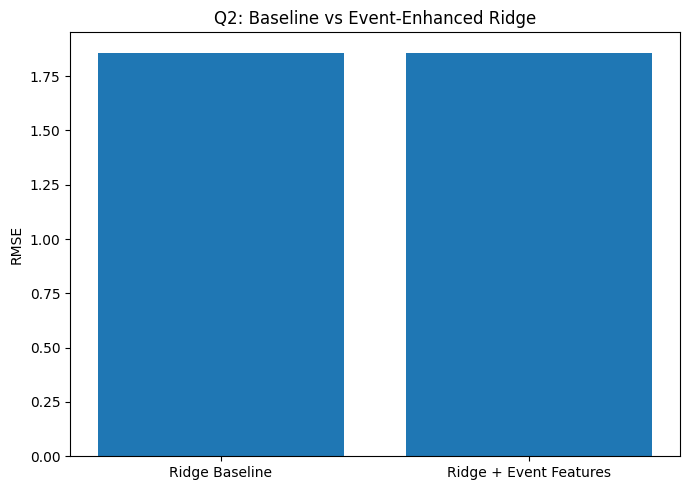

In [68]:
import matplotlib.pyplot as plt

plot_df = q2_test_results.copy()

x = np.arange(len(plot_df))

plt.figure(figsize=(7,5))
plt.bar(x, plot_df["RMSE"])
plt.xticks(x, plot_df["Model"])
plt.ylabel("RMSE")
plt.title("Q2: Baseline vs Event-Enhanced Ridge")
plt.tight_layout()

plt.savefig(
    f"{Q2_PATH}/q2_rmse_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [69]:
# ============================================================
# FINAL Q2 DASHBOARD HANDOFF PACKAGE
# Carbon Pulse - Event Impact Analysis
# ============================================================

import os
import json
import pickle
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. CREATE FOLDERS
# ------------------------------------------------------------

Q2_PATH = (
    "/content/drive/MyDrive/Datathon_2026/"
    "Q2_Event_Analysis_Final"
)

MODEL_PATH = f"{Q2_PATH}/models"

os.makedirs(Q2_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

print("Creating Q2 package...")


# ============================================================
# 2. SAVE ORIGINAL WORKING INPUT DATA
# ============================================================

carbon_clean.to_csv(
    f"{Q2_PATH}/carbon_prices_daily_clean.csv",
    index=False
)

events_clean.to_csv(
    f"{Q2_PATH}/climate_events_clean.csv",
    index=False
)

print("✅ Input datasets saved")


# ============================================================
# 3. SAVE ENGINEERED EVENT DATASET
# ============================================================

# Complete modelling dataset including historical + event features
q2_model_df.to_csv(
    f"{Q2_PATH}/event_features.csv",
    index=False
)

print("✅ Engineered event dataset saved")


# ============================================================
# 4. FEATURE MANIFEST
# ============================================================

feature_manifest = pd.DataFrame({
    "feature": [
        "days_since_last_event",
        "events_7d",
        "events_30d",
        "max_severity_7d",
        "max_severity_30d",
        "policy_events_30d",
        "weather_events_30d",
        "disaster_events_30d",
        "event_shock_score"
    ],

    "description": [
        "Days elapsed since most recent relevant event",
        "Number of relevant events during previous 7 days",
        "Number of relevant events during previous 30 days",
        "Maximum event severity during previous 7 days",
        "Maximum event severity during previous 30 days",
        "Number of policy events during previous 30 days",
        "Number of extreme-weather events during previous 30 days",
        "Number of disaster events during previous 30 days",
        "Severity-weighted exponentially decaying recent-event signal"
    ],

    "leakage_safe": [
        True, True, True, True, True,
        True, True, True, True
    ]
})

feature_manifest.to_csv(
    f"{Q2_PATH}/event_feature_manifest.csv",
    index=False
)

print("✅ Feature manifest saved")


# ============================================================
# 5. SAVE FINAL TEST PREDICTIONS
# ============================================================

event_impact_results = q2_test.copy()

event_impact_results["baseline_prediction"] = pred_base_test
event_impact_results["event_aware_prediction"] = pred_event_test

event_impact_results["baseline_abs_error"] = np.abs(
    event_impact_results["price"]
    - event_impact_results["baseline_prediction"]
)

event_impact_results["event_aware_abs_error"] = np.abs(
    event_impact_results["price"]
    - event_impact_results["event_aware_prediction"]
)

# Useful dashboard flag
event_impact_results["event_active_30d"] = (
    event_impact_results["events_30d"] > 0
).astype(int)

keep_cols = [
    "date",
    "market",
    "currency",
    "price",

    "baseline_prediction",
    "event_aware_prediction",

    "baseline_abs_error",
    "event_aware_abs_error",

    "days_since_last_event",
    "events_7d",
    "events_30d",
    "max_severity_7d",
    "max_severity_30d",

    "policy_events_30d",
    "weather_events_30d",
    "disaster_events_30d",

    "event_shock_score",
    "event_active_30d"
]

keep_cols = [
    c for c in keep_cols
    if c in event_impact_results.columns
]

event_impact_results[keep_cols].to_csv(
    f"{Q2_PATH}/event_impact_results.csv",
    index=False
)

print("✅ Event impact results saved")


# ============================================================
# 6. FINAL PERFORMANCE COMPARISON
# ============================================================

comparison = pd.DataFrame({
    "model": [
        "Ridge Baseline",
        "Ridge + Event Features"
    ],

    "rmse": [
        float(base_test_rmse),
        float(event_test_rmse)
    ],

    "mae": [
        float(base_test_mae),
        float(event_test_mae)
    ],

    "mape_percent": [
        float(base_test_mape),
        float(event_test_mape)
    ]
})

comparison.to_csv(
    f"{Q2_PATH}/event_model_comparison.csv",
    index=False
)

print("✅ Model comparison saved")


# ============================================================
# 7. FEATURE CONTRIBUTION / IMPORTANCE
# Ridge coefficients
# ============================================================

coef_df = pd.DataFrame({
    "feature": list(event_cols_final),
    "coefficient": ridge_event_final.coef_
})

coef_df["abs_coefficient"] = np.abs(
    coef_df["coefficient"]
)

# Only extract event-related features
event_feature_names = [
    "days_since_last_event",
    "events_7d",
    "events_30d",
    "max_severity_7d",
    "max_severity_30d",
    "policy_events_30d",
    "weather_events_30d",
    "disaster_events_30d",
    "event_shock_score"
]

event_importance = coef_df[
    coef_df["feature"].isin(event_feature_names)
].copy()

event_importance = event_importance.sort_values(
    "abs_coefficient",
    ascending=False
)

event_importance.to_csv(
    f"{Q2_PATH}/event_feature_importance.csv",
    index=False
)

print("✅ Event feature contribution saved")


# ============================================================
# 8. SAVE TRAINED MODELS + SCALERS
# ============================================================

baseline_bundle = {
    "model": ridge_base_final,
    "scaler": scaler_base_final,
    "feature_columns": list(base_cols_final),
    "model_name": "Ridge Regression",
    "event_features_used": False
}

event_bundle = {
    "model": ridge_event_final,
    "scaler": scaler_event_final,
    "feature_columns": list(event_cols_final),
    "model_name": "Ridge Regression",
    "event_features_used": True
}

with open(
    f"{MODEL_PATH}/ridge_baseline.pkl",
    "wb"
) as f:
    pickle.dump(baseline_bundle, f)

with open(
    f"{MODEL_PATH}/ridge_event_aware.pkl",
    "wb"
) as f:
    pickle.dump(event_bundle, f)

print("✅ Trained models saved")


# ============================================================
# 9. EVENT-WINDOW RESULTS
# ============================================================

event_window_rows = event_impact_results[
    event_impact_results["events_30d"] > 0
].copy()

if len(event_window_rows) > 0:

    baseline_event_rmse = np.sqrt(
        np.mean(
            (
                event_window_rows["price"]
                - event_window_rows["baseline_prediction"]
            ) ** 2
        )
    )

    enhanced_event_rmse = np.sqrt(
        np.mean(
            (
                event_window_rows["price"]
                - event_window_rows["event_aware_prediction"]
            ) ** 2
        )
    )

    event_window_improvement = (
        (
            baseline_event_rmse
            - enhanced_event_rmse
        )
        / baseline_event_rmse
    ) * 100

else:

    baseline_event_rmse = None
    enhanced_event_rmse = None
    event_window_improvement = None


event_window_summary = pd.DataFrame({
    "metric": [
        "event_window_rows",
        "baseline_event_window_rmse",
        "event_aware_event_window_rmse",
        "event_window_improvement_percent"
    ],

    "value": [
        len(event_window_rows),
        baseline_event_rmse,
        enhanced_event_rmse,
        event_window_improvement
    ]
})

event_window_summary.to_csv(
    f"{Q2_PATH}/event_window_analysis.csv",
    index=False
)

print("✅ Event-window analysis saved")


# ============================================================
# 10. JSON FOR DASHBOARD
# ============================================================

rmse_improvement = (
    (base_test_rmse - event_test_rmse)
    / base_test_rmse
) * 100

mape_improvement = (
    (base_test_mape - event_test_mape)
    / base_test_mape
) * 100


important_features = (
    event_importance["feature"]
    .head(5)
    .tolist()
)


dashboard_json = {

    "task": "Q2 Climate and Policy Event Impact",

    "model_type": "Ridge Regression",

    "baseline": {
        "rmse": float(base_test_rmse),
        "mae": float(base_test_mae),
        "mape_percent": float(base_test_mape)
    },

    "event_aware": {
        "rmse": float(event_test_rmse),
        "mae": float(event_test_mae),
        "mape_percent": float(event_test_mape)
    },

    "rmse_improvement_percent":
        float(rmse_improvement),

    "mape_improvement_percent":
        float(mape_improvement),

    "event_window": {
        "rows": int(len(event_window_rows)),
        "baseline_rmse":
            (
                float(baseline_event_rmse)
                if baseline_event_rmse is not None
                else None
            ),

        "event_aware_rmse":
            (
                float(enhanced_event_rmse)
                if enhanced_event_rmse is not None
                else None
            ),

        "improvement_percent":
            (
                float(event_window_improvement)
                if event_window_improvement is not None
                else None
            )
    },

    "important_event_features":
        important_features,

    "interpretation":
        (
            "Event features produced negligible improvement "
            "in short-term carbon-price level prediction. "
            "Historical price dynamics remained the dominant "
            "predictive signal."
        )
}


with open(
    f"{Q2_PATH}/q2_dashboard_summary.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        dashboard_json,
        f,
        indent=4
    )

print("✅ Dashboard JSON saved")


# ============================================================
# 11. MODEL COMPARISON CHART
# ============================================================

plt.figure(figsize=(7, 5))

plt.bar(
    comparison["model"],
    comparison["rmse"]
)

plt.ylabel("RMSE")
plt.title(
    "Q2: Baseline vs Event-Aware Carbon Price Model"
)

plt.xticks(rotation=10)

plt.tight_layout()

plt.savefig(
    f"{Q2_PATH}/event_model_rmse_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("✅ RMSE chart saved")


# ============================================================
# 12. EVENT FEATURE IMPORTANCE CHART
# ============================================================

if len(event_importance) > 0:

    plot_imp = (
        event_importance
        .sort_values(
            "abs_coefficient",
            ascending=True
        )
    )

    plt.figure(figsize=(8, 5))

    plt.barh(
        plot_imp["feature"],
        plot_imp["abs_coefficient"]
    )

    plt.xlabel(
        "Absolute Standardized Ridge Coefficient"
    )

    plt.title(
        "Contribution of Event Features"
    )

    plt.tight_layout()

    plt.savefig(
        f"{Q2_PATH}/event_feature_importance.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

print("✅ Feature importance chart saved")


# ============================================================
# 13. README
# ============================================================

readme = f"""
CODEFEST DATATHON 2026
Q2 - Climate & Policy Event Impact on Carbon Prices
====================================================

OBJECTIVE
---------
Test whether climate and policy event information improves
carbon-price prediction.

EXPERIMENT DESIGN
-----------------
Two Ridge Regression models were compared.

MODEL A - BASELINE
Historical price, calendar, lag, rolling and momentum features.

MODEL B - EVENT-AWARE
Exactly the same Ridge modelling approach as Model A,
with additional climate/policy event features.

This ensures that the comparison isolates the predictive
contribution of event information.

EVENT FEATURES
--------------
- days_since_last_event
- events_7d
- events_30d
- max_severity_7d
- max_severity_30d
- policy_events_30d
- weather_events_30d
- disaster_events_30d
- event_shock_score

LEAKAGE CONTROL
---------------
Only events occurring on or before each carbon-price date were
used.

days_until_next_event was NOT used for general climate events,
because future unscheduled events would introduce information
that would not be available at prediction time.

MODEL
-----
Ridge Regression

FINAL UNTOUCHED TEST RESULTS
----------------------------
Baseline RMSE:
{base_test_rmse:.6f}

Event-Aware RMSE:
{event_test_rmse:.6f}

Baseline MAE:
{base_test_mae:.6f}

Event-Aware MAE:
{event_test_mae:.6f}

Baseline MAPE:
{base_test_mape:.6f}%

Event-Aware MAPE:
{event_test_mape:.6f}%

RMSE Improvement:
{rmse_improvement:.4f}%

MAPE Improvement:
{mape_improvement:.4f}%

EVENT-WINDOW ANALYSIS
---------------------
Event-window rows:
{len(event_window_rows)}

Baseline event-window RMSE:
{baseline_event_rmse}

Event-aware event-window RMSE:
{enhanced_event_rmse}

Event-window improvement:
{event_window_improvement}%

INTERPRETATION
--------------
Adding event-proximity variables produced negligible improvement
in short-term carbon-price level prediction.

The event-aware model reduced overall RMSE only marginally,
while MAE/MAPE did not materially improve.

This suggests historical carbon-price dynamics were more useful
for short-term price prediction than the sparse climate-event
catalogue.

Event indicators may therefore be more useful as contextual
risk / alert signals in the Carbon Pulse dashboard than as major
drivers of point forecasts.

FILES
-----
carbon_prices_daily_clean.csv
    Carbon-price working data.

climate_events_clean.csv
    Climate and policy event working data.

event_features.csv
    Full modelling dataset with engineered features.

event_feature_manifest.csv
    Definitions of event features.

event_model_comparison.csv
    Baseline vs event-aware metrics.

event_impact_results.csv
    Row-level test predictions and event signals.

event_feature_importance.csv
    Standardized Ridge coefficients for event variables.

event_window_analysis.csv
    Performance specifically during event-active periods.

q2_dashboard_summary.json
    Compact values for direct dashboard integration.

models/ridge_baseline.pkl
    Baseline trained model + scaler + feature list.

models/ridge_event_aware.pkl
    Event-aware trained model + scaler + feature list.

event_model_rmse_comparison.png
    Model performance chart.

event_feature_importance.png
    Event-feature contribution chart.
"""

with open(
    f"{Q2_PATH}/README_Q2.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write(readme)

print("✅ README saved")


# ============================================================
# 14. LIST PACKAGE CONTENT
# ============================================================

print("\n" + "=" * 60)
print("FINAL Q2 PACKAGE")
print("=" * 60)

for root, dirs, files in os.walk(Q2_PATH):

    level = root.replace(
        Q2_PATH, ""
    ).count(os.sep)

    indent = "    " * level

    print(
        f"{indent}{os.path.basename(root)}/"
    )

    for filename in files:

        print(
            f"{indent}    {filename}"
        )


# ============================================================
# 15. ZIP EVERYTHING
# ============================================================

ZIP_BASE = (
    "/content/drive/MyDrive/Datathon_2026/"
    "Q2_Event_Analysis_Final"
)

zip_path = shutil.make_archive(
    ZIP_BASE,
    "zip",
    Q2_PATH
)

print("\n✅ Q2 ZIP CREATED")
print(zip_path)

Creating Q2 package...
✅ Input datasets saved
✅ Engineered event dataset saved
✅ Feature manifest saved
✅ Event impact results saved
✅ Model comparison saved
✅ Event feature contribution saved
✅ Trained models saved
✅ Event-window analysis saved
✅ Dashboard JSON saved
✅ RMSE chart saved
✅ Feature importance chart saved
✅ README saved

FINAL Q2 PACKAGE
Q2_Event_Analysis_Final/
    carbon_prices_daily_clean.csv
    climate_events_clean.csv
    event_features.csv
    event_feature_manifest.csv
    event_impact_results.csv
    event_model_comparison.csv
    event_feature_importance.csv
    event_window_analysis.csv
    q2_dashboard_summary.json
    event_model_rmse_comparison.png
    event_feature_importance.png
    README_Q2.txt
    models/
        ridge_baseline.pkl
        ridge_event_aware.pkl

✅ Q2 ZIP CREATED
/content/drive/MyDrive/Datathon_2026/Q2_Event_Analysis_Final.zip


In [70]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/Datathon_2026/"
    "Q2_Event_Analysis_Final.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Q3

In [72]:
print(df3.columns.tolist())

['year', 'country_x', 'iso3', 'region_x', 'coal_pct', 'oil_pct', 'gas_pct', 'nuclear_pct', 'hydro_pct', 'solar_pct', 'wind_pct', 'other_renewables_pct', 'renewables_total_pct', 'fossil_total_pct', 'country_y', 'region_y', 'co2_emissions_mt', 'co2_per_capita_t', 'population_millions']


In [73]:
# ============================================================
# FIX DUPLICATED COUNTRY / REGION COLUMNS AFTER MERGE
# ============================================================

df3 = energy_clean.merge(
    co2_clean[
        [
            "year",
            "iso3",
            "country",
            "region",
            "co2_emissions_mt",
            "co2_per_capita_t",
            "population_millions"
        ]
    ],
    on=["year", "iso3"],
    how="inner",
    suffixes=("_energy", "_co2")
)

# Use one clean country/region column
df3["country"] = df3["country_energy"]
df3["region"] = df3["region_energy"]

# Drop duplicated versions
df3 = df3.drop(
    columns=[
        "country_energy",
        "country_co2",
        "region_energy",
        "region_co2"
    ],
    errors="ignore"
)

df3 = (
    df3
    .sort_values(["iso3", "year"])
    .reset_index(drop=True)
)

print("Shape:", df3.shape)
print("Countries:", df3["country"].nunique())
print("Years:", df3["year"].min(), "-", df3["year"].max())

display(df3.head())

Shape: (1350, 17)
Countries: 50
Years: 2000 - 2026


,year,iso3,coal_pct,oil_pct,gas_pct,nuclear_pct,hydro_pct,solar_pct,wind_pct,other_renewables_pct,renewables_total_pct,fossil_total_pct,co2_emissions_mt,co2_per_capita_t,population_millions,country,region
0,2000,ARE,0.19,51.84,44.66,1.44,0.53,0.00,1.01,0.32,1.86,96.70,107.6,13.33,8.1,UAE,MENA
1,2001,ARE,0.00,49.62,46.40,0.63,1.42,0.22,1.34,0.38,3.35,96.02,115.0,14.13,8.1,UAE,MENA
2,2002,ARE,1.75,49.81,46.29,0.18,1.03,0.28,0.00,0.65,1.96,97.85,121.5,14.81,8.2,UAE,MENA
3,2003,ARE,0.42,50.14,44.77,0.68,0.00,0.21,1.15,2.62,3.98,95.34,128.0,15.48,8.3,UAE,MENA
4,2004,ARE,0.87,47.08,42.03,2.50,2.92,0.89,2.61,1.11,7.53,89.97,135.0,16.20,8.3,UAE,MENA


In [75]:
print(df3.columns.tolist())

['year', 'iso3', 'coal_pct', 'oil_pct', 'gas_pct', 'nuclear_pct', 'hydro_pct', 'solar_pct', 'wind_pct', 'other_renewables_pct', 'renewables_total_pct', 'fossil_total_pct', 'co2_emissions_mt', 'co2_per_capita_t', 'population_millions', 'country', 'region']


In [76]:
# ============================================================
# Q3 — STEP 2
# GLOBAL TRANSITION SUMMARY
# ============================================================

global_transition = (
    df3.groupby("year")
    .agg(
        avg_renewables=("renewables_total_pct", "mean"),
        avg_fossil=("fossil_total_pct", "mean"),
        avg_co2_pc=("co2_per_capita_t", "mean")
    )
    .reset_index()
)

display(global_transition.head())

start = global_transition.iloc[0]
end = global_transition.iloc[-1]

print(
    f"Renewables: {start['avg_renewables']:.2f}% "
    f"→ {end['avg_renewables']:.2f}%"
)

print(
    f"Fossil fuels: {start['avg_fossil']:.2f}% "
    f"→ {end['avg_fossil']:.2f}%"
)

print(
    f"CO2 per capita: {start['avg_co2_pc']:.2f} "
    f"→ {end['avg_co2_pc']:.2f}"
)

,year,avg_renewables,avg_fossil,avg_co2_pc
0,2000,13.0352,81.5872,7.3992
1,2001,13.3816,81.4272,7.4800
2,2002,13.7744,81.0348,7.6214
3,2003,14.0878,80.5808,7.5892
4,2004,13.9318,80.7190,7.7034


Renewables: 13.04% → 22.98%
Fossil fuels: 81.59% → 71.89%
CO2 per capita: 7.40 → 7.21


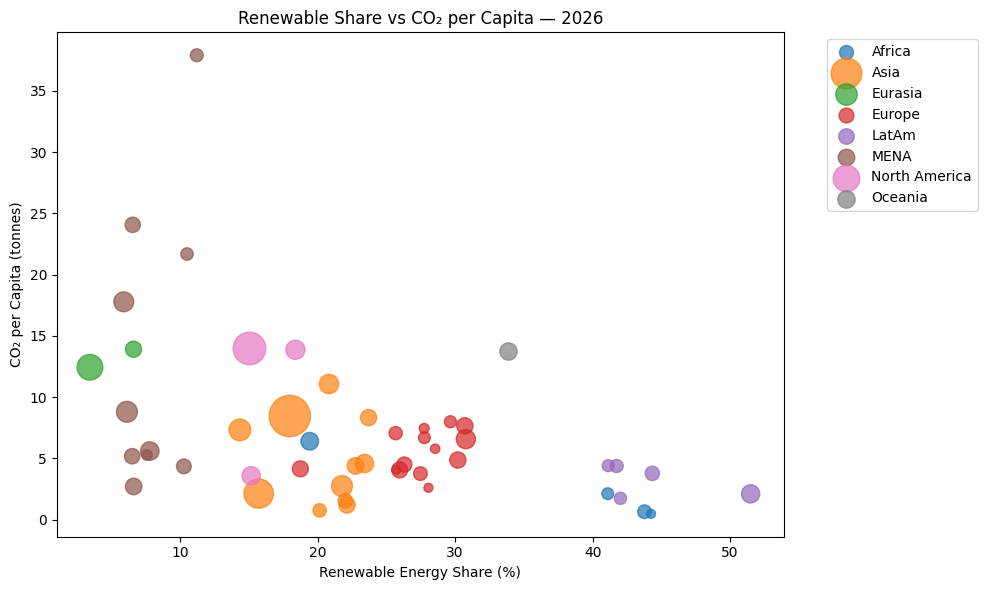

In [77]:
# ============================================================
# Q3 — STEP 3
# HERO SCATTER
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

latest_year = df3["year"].max()

latest = df3[
    df3["year"] == latest_year
].copy()

plt.figure(figsize=(10, 6))

for region, g in latest.groupby("region"):

    plt.scatter(
        g["renewables_total_pct"],
        g["co2_per_capita_t"],
        s=np.sqrt(g["co2_emissions_mt"]) * 8,
        alpha=0.7,
        label=region
    )

plt.xlabel("Renewable Energy Share (%)")
plt.ylabel("CO₂ per Capita (tonnes)")
plt.title(
    f"Renewable Share vs CO₂ per Capita — {latest_year}"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [78]:
# ============================================================
# Q3 — STEP 4
# COUNTRY TRANSITION FINGERPRINTS
# ============================================================

records = []

for country, g in df3.groupby("country"):

    g = g.sort_values("year").copy()

    first = g.iloc[0]
    last = g.iloc[-1]

    years = g["year"].values

    renewable_slope = np.polyfit(
        years,
        g["renewables_total_pct"],
        1
    )[0]

    fossil_slope = np.polyfit(
        years,
        g["fossil_total_pct"],
        1
    )[0]

    co2_slope = np.polyfit(
        years,
        g["co2_per_capita_t"],
        1
    )[0]

    recent = g[g["year"] >= 2022]

    recent_renewable_slope = np.polyfit(
        recent["year"],
        recent["renewables_total_pct"],
        1
    )[0]

    recent_co2_slope = np.polyfit(
        recent["year"],
        recent["co2_per_capita_t"],
        1
    )[0]

    records.append({
        "country": country,
        "iso3": last["iso3"],
        "region": last["region"],

        "renewable_2000":
            first["renewables_total_pct"],

        "renewable_2026":
            last["renewables_total_pct"],

        "renewable_change_pp":
            last["renewables_total_pct"]
            - first["renewables_total_pct"],

        "fossil_2000":
            first["fossil_total_pct"],

        "fossil_2026":
            last["fossil_total_pct"],

        "fossil_change_pp":
            last["fossil_total_pct"]
            - first["fossil_total_pct"],

        "co2_2000":
            first["co2_per_capita_t"],

        "co2_2026":
            last["co2_per_capita_t"],

        "co2_change":
            last["co2_per_capita_t"]
            - first["co2_per_capita_t"],

        "renewable_slope":
            renewable_slope,

        "fossil_slope":
            fossil_slope,

        "co2_slope":
            co2_slope,

        "recent_renewable_slope":
            recent_renewable_slope,

        "recent_co2_slope":
            recent_co2_slope
    })

transition_df = pd.DataFrame(records)

print("Shape:", transition_df.shape)

display(
    transition_df.sort_values(
        "renewable_change_pp",
        ascending=False
    ).head(10)
)

Shape: (50, 17)


,country,iso3,region,renewable_2000,renewable_2026,renewable_change_pp,fossil_2000,fossil_2026,fossil_change_pp,co2_2000,co2_2026,co2_change,renewable_slope,fossil_slope,co2_slope,recent_renewable_slope,recent_co2_slope
15,Germany,DEU,Europe,2.44,30.78,28.34,84.81,68.99,-15.82,12.00,6.57,-5.43,1.057912,-0.543431,-0.215397,1.774,-0.210
46,United Kingdom,GBR,Europe,0.70,25.97,25.27,91.27,66.37,-24.90,10.03,4.06,-5.97,1.051893,-1.097961,-0.250855,1.155,-0.162
2,Australia,AUS,Oceania,12.25,33.84,21.59,87.22,65.69,-21.53,16.52,13.78,-2.74,0.891941,-0.869444,-0.111801,1.603,-0.185
34,Poland,POL,Europe,10.43,30.71,20.28,80.53,59.83,-20.70,10.19,7.66,-2.53,0.700488,-0.748571,-0.101514,1.240,-0.089
21,Italy,ITA,Europe,11.08,30.20,19.12,80.09,59.47,-20.62,9.46,4.87,-4.59,0.686111,-0.695482,-0.197637,1.398,-0.078
10,Czech Republic,CZE,Europe,11.36,29.66,18.30,77.61,60.16,-17.45,13.98,7.99,-5.99,0.699872,-0.695696,-0.244463,1.376,-0.109
4,Belgium,BEL,Europe,9.57,27.77,18.20,81.43,63.16,-18.27,12.55,6.69,-5.86,0.748535,-0.732845,-0.246978,0.702,-0.167
45,Ukraine,UKR,Europe,9.42,27.48,18.06,78.15,63.27,-14.88,10.28,3.76,-6.52,0.668223,-0.639512,-0.261679,0.574,-0.228
13,Finland,FIN,Europe,10.94,28.55,17.61,77.98,62.58,-15.40,14.02,5.79,-8.23,0.649261,-0.626581,-0.359286,0.912,-0.207
40,Spain,ESP,Europe,8.94,26.31,17.37,81.73,62.49,-19.24,7.62,4.50,-3.12,0.718871,-0.735305,-0.130971,-0.205,-0.069


In [79]:
# ============================================================
# Q3 — STEP 5
# KMEANS ARCHETYPES
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_features = [
    "renewable_change_pp",
    "fossil_change_pp",
    "co2_change",
    "renewable_slope",
    "fossil_slope",
    "co2_slope",
    "recent_renewable_slope",
    "recent_co2_slope"
]

X = transition_df[
    cluster_features
].copy()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

transition_df["cluster"] = (
    kmeans.fit_predict(X_scaled)
)

transition_df["transition_score"] = (
      transition_df["renewable_change_pp"]
    - transition_df["fossil_change_pp"]
    - transition_df["co2_change"]
)

cluster_scores = (
    transition_df
    .groupby("cluster")["transition_score"]
    .mean()
    .sort_values()
)

ordered = cluster_scores.index.tolist()

label_map = {
    ordered[0]: "BAU",
    ordered[1]: "Moderate",
    ordered[2]: "Accelerated"
}

transition_df["trajectory"] = (
    transition_df["cluster"]
    .map(label_map)
)

print("Trajectory counts:")
print(
    transition_df["trajectory"]
    .value_counts()
)

display(
    transition_df[
        [
            "country",
            "renewable_change_pp",
            "fossil_change_pp",
            "co2_change",
            "trajectory"
        ]
    ].sort_values(
        ["trajectory", "renewable_change_pp"],
        ascending=[True, False]
    )
)

Trajectory counts:
trajectory
BAU            20
Moderate       15
Accelerated    15
Name: count, dtype: int64


,country,renewable_change_pp,fossil_change_pp,co2_change,trajectory
15,Germany,28.34,-15.82,-5.43,Accelerated
46,United Kingdom,25.27,-24.90,-5.97,Accelerated
2,Australia,21.59,-21.53,-2.74,Accelerated
34,Poland,20.28,-20.70,-2.53,Accelerated
21,Italy,19.12,-20.62,-4.59,Accelerated
10,Czech Republic,18.30,-17.45,-5.99,Accelerated
4,Belgium,18.20,-18.27,-5.86,Accelerated
45,Ukraine,18.06,-14.88,-6.52,Accelerated
13,Finland,17.61,-15.40,-8.23,Accelerated
40,Spain,17.37,-19.24,-3.12,Accelerated


In [80]:
# ============================================================
# Q3.2 — STEP 1
# SELECT 2 REPRESENTATIVE COUNTRIES FROM EACH ARCHETYPE
# ============================================================

from sklearn.metrics import pairwise_distances

distances = pairwise_distances(
    X_scaled,
    kmeans.cluster_centers_
)

transition_df["cluster_distance"] = [
    distances[i, c]
    for i, c in enumerate(transition_df["cluster"])
]

representative_countries = (
    transition_df
    .sort_values("cluster_distance")
    .groupby("trajectory")
    .head(2)
)

display(
    representative_countries[
        [
            "country",
            "trajectory",
            "renewable_change_pp",
            "fossil_change_pp",
            "co2_change",
            "cluster_distance"
        ]
    ]
)

,country,trajectory,renewable_change_pp,fossil_change_pp,co2_change,cluster_distance
43,Turkey,BAU,4.40,-5.03,2.53,0.526355
4,Belgium,Accelerated,18.20,-18.27,-5.86,0.593473
0,Algeria,BAU,5.64,-4.95,1.68,0.601450
48,Venezuela,Moderate,8.32,-11.06,-1.59,0.628341
1,Argentina,Moderate,10.58,-9.96,0.23,0.828297
10,Czech Republic,Accelerated,18.30,-17.45,-5.99,0.900287


In [81]:
# ============================================================
# Q3.2 — STEP 2
# RECENT CO2 CAGR: 2018 → 2026
# ============================================================

selected_countries = representative_countries["country"].tolist()

scenario_inputs = []

for country in selected_countries:

    g = (
        df3[df3["country"] == country]
        .sort_values("year")
    )

    row_2018 = g[g["year"] == 2018].iloc[0]
    row_2026 = g[g["year"] == 2026].iloc[0]

    start_val = row_2018["co2_per_capita_t"]
    end_val = row_2026["co2_per_capita_t"]

    recent_cagr = (
        (end_val / start_val) ** (1 / 8)
        - 1
    )

    trajectory = (
        transition_df.loc[
            transition_df["country"] == country,
            "trajectory"
        ].iloc[0]
    )

    scenario_inputs.append({
        "country": country,
        "trajectory": trajectory,
        "co2_2018": start_val,
        "co2_2026": end_val,
        "recent_cagr": recent_cagr
    })

scenario_inputs = pd.DataFrame(scenario_inputs)

display(
    scenario_inputs.round(4)
)

,country,trajectory,co2_2018,co2_2026,recent_cagr
0,Turkey,BAU,5.08,5.60,0.0123
1,Belgium,Accelerated,8.07,6.69,-0.0232
2,Algeria,BAU,3.93,4.35,0.0128
3,Venezuela,Moderate,5.37,4.38,-0.0252
4,Argentina,Moderate,4.06,3.78,-0.0089
5,Czech Republic,Accelerated,9.58,7.99,-0.0224


In [82]:
# ============================================================
# Q3.2 — STEP 3
# 2026 → 2030 CO2 SCENARIOS
# ============================================================

scenario_rows = []

for _, row in scenario_inputs.iterrows():

    country = row["country"]
    base_value = row["co2_2026"]
    recent_cagr = row["recent_cagr"]

    scenario_rates = {
        "BAU": recent_cagr,
        "Moderate": recent_cagr - 0.015,
        "Accelerated": recent_cagr - 0.035
    }

    # observed starting point
    for scenario in scenario_rates.keys():

        scenario_rows.append({
            "country": country,
            "year": 2026,
            "scenario": scenario,
            "co2_per_capita_t": base_value,
            "annual_rate": scenario_rates[scenario]
        })

    # future years
    for scenario, rate in scenario_rates.items():

        value = base_value

        for year in range(2027, 2031):

            value = value * (1 + rate)

            value = max(value, 0)

            scenario_rows.append({
                "country": country,
                "year": year,
                "scenario": scenario,
                "co2_per_capita_t": value,
                "annual_rate": rate
            })

scenario_df = pd.DataFrame(scenario_rows)

display(
    scenario_df.head(20)
)

,country,year,scenario,co2_per_capita_t,annual_rate
0,Turkey,2026,BAU,5.600000,0.012256
1,Turkey,2026,Moderate,5.600000,-0.002744
2,Turkey,2026,Accelerated,5.600000,-0.022744
3,Turkey,2027,BAU,5.668636,0.012256
4,Turkey,2028,BAU,5.738113,0.012256
5,Turkey,2029,BAU,5.808442,0.012256
6,Turkey,2030,BAU,5.879633,0.012256
7,Turkey,2027,Moderate,5.584636,-0.002744
8,Turkey,2028,Moderate,5.569314,-0.002744
9,Turkey,2029,Moderate,5.554034,-0.002744


In [83]:
# ============================================================
# Q3.2 — STEP 4
# 2030 SUMMARY TABLE
# ============================================================

scenario_2030 = (
    scenario_df[
        scenario_df["year"] == 2030
    ]
    .pivot(
        index="country",
        columns="scenario",
        values="co2_per_capita_t"
    )
    .reset_index()
)

display(
    scenario_2030.round(2)
)

scenario,country,Accelerated,BAU,Moderate
0,Algeria,3.98,4.58,4.31
1,Argentina,3.16,3.65,3.43
2,Belgium,5.26,6.09,5.73
3,Czech Republic,6.31,7.30,6.86
4,Turkey,5.11,5.88,5.54
5,Venezuela,3.42,3.96,3.72


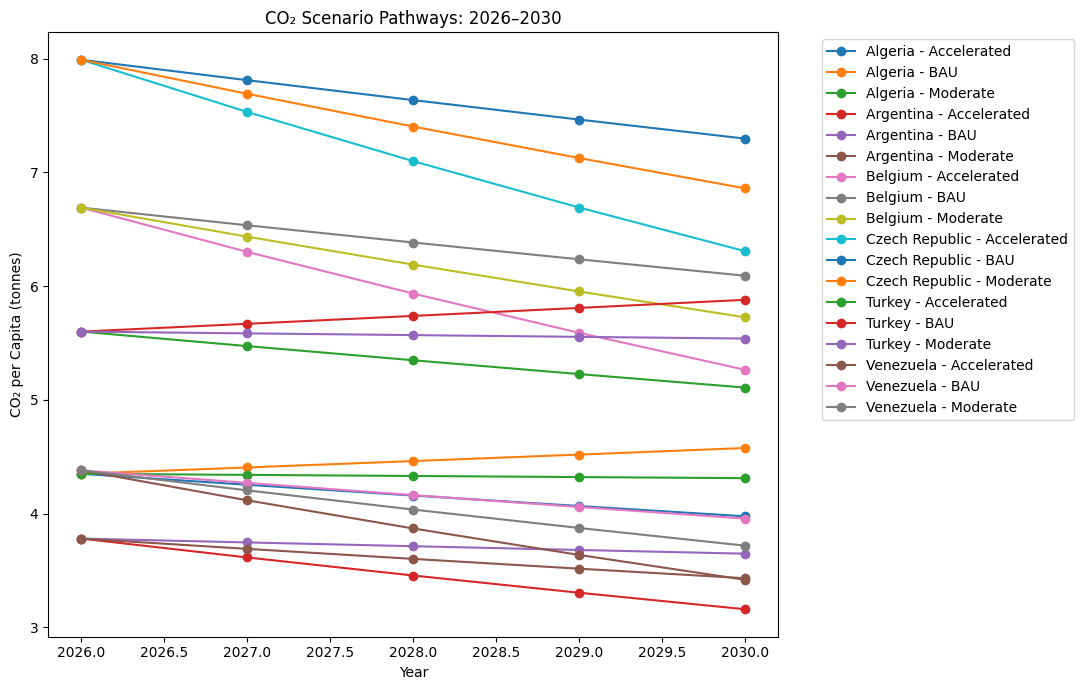

In [84]:
# ============================================================
# Q3.2 — STEP 5
# SCENARIO CHART
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(11, 7))

for (country, scenario), g in scenario_df.groupby(
    ["country", "scenario"]
):

    plt.plot(
        g["year"],
        g["co2_per_capita_t"],
        marker="o",
        label=f"{country} - {scenario}"
    )

plt.xlabel("Year")
plt.ylabel("CO₂ per Capita (tonnes)")
plt.title("CO₂ Scenario Pathways: 2026–2030")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Selected for clean chart:
      country   trajectory
43     Turkey          BAU
4     Belgium  Accelerated
48  Venezuela     Moderate


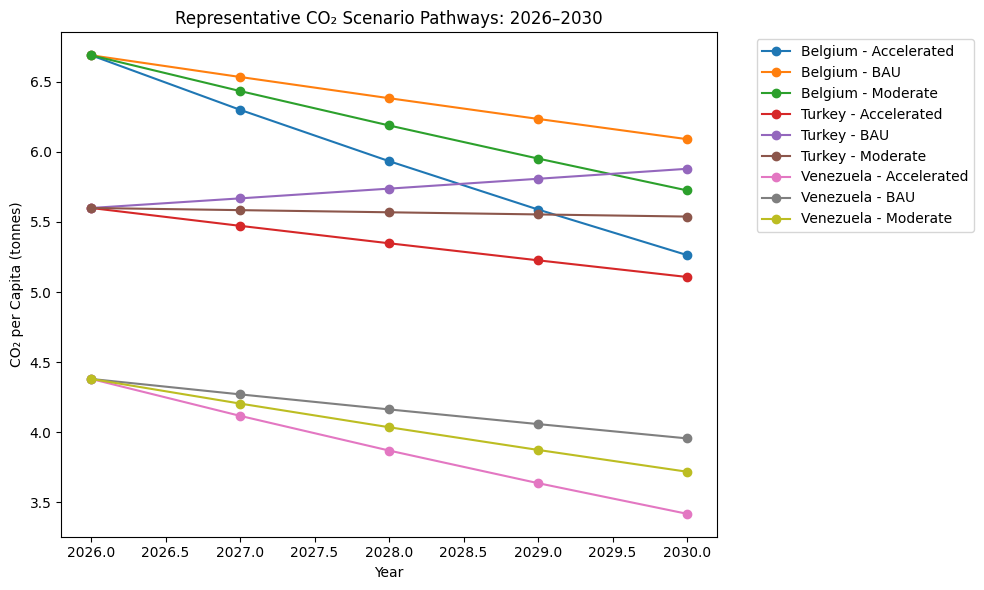

In [85]:
# ============================================================
# CLEAN Q3 SCENARIO CHART
# 1 representative country per archetype
# ============================================================

one_per_group = (
    representative_countries
    .sort_values("cluster_distance")
    .groupby("trajectory")
    .head(1)
)

selected_for_chart = one_per_group["country"].tolist()

print("Selected for clean chart:")
print(
    one_per_group[
        ["country", "trajectory"]
    ]
)

plot_df = scenario_df[
    scenario_df["country"].isin(selected_for_chart)
].copy()

plt.figure(figsize=(10, 6))

for (country, scenario), g in plot_df.groupby(
    ["country", "scenario"]
):
    plt.plot(
        g["year"],
        g["co2_per_capita_t"],
        marker="o",
        label=f"{country} - {scenario}"
    )

plt.xlabel("Year")
plt.ylabel("CO₂ per Capita (tonnes)")
plt.title("Representative CO₂ Scenario Pathways: 2026–2030")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [86]:
scenario_2030 = (
    scenario_df[
        scenario_df["year"] == 2030
    ]
    .pivot(
        index="country",
        columns="scenario",
        values="co2_per_capita_t"
    )
    .reset_index()
)

display(
    scenario_2030.round(2)
)

scenario,country,Accelerated,BAU,Moderate
0,Algeria,3.98,4.58,4.31
1,Argentina,3.16,3.65,3.43
2,Belgium,5.26,6.09,5.73
3,Czech Republic,6.31,7.30,6.86
4,Turkey,5.11,5.88,5.54
5,Venezuela,3.42,3.96,3.72


1. The global energy transition is visible but incomplete. Renewable share increased substantially from 2000 to 2026 while fossil-fuel share declined, but average CO₂ per capita declined much more slowly.

2. Countries do not follow one common transition path. The clustering identified three distinct historical archetypes: 20 BAU, 15 Moderate, and 15 Accelerated.

3. Accelerated-transition countries show the clearest structural change. Countries such as Germany, the United Kingdom, Belgium, Spain and Finland combine strong renewable growth with declining fossil shares and lower CO₂ per capita.

4. Scenario differences become more important over time. By 2030, every representative country shows lower CO₂ per capita under the Accelerated pathway than under BAU, demonstrating the cumulative effect of sustained annual reductions.

5. Short-term and long-term climate intelligence serve different purposes. Q2 showed that event variables added almost no improvement to short-term carbon-price prediction, while Q3 reveals much stronger structural differences in long-term transition trajectories.

In [87]:
# ============================================================
# FINAL Q3 DASHBOARD PACKAGE
# ============================================================

import os
import json
import shutil
import pandas as pd

Q3_PATH = (
    "/content/drive/MyDrive/Datathon_2026/"
    "Q3_Transition_Analysis_Final"
)

os.makedirs(Q3_PATH, exist_ok=True)

# ------------------------------------------------------------
# 1. MAIN OUTPUTS
# ------------------------------------------------------------

global_transition.to_csv(
    f"{Q3_PATH}/global_transition_trends.csv",
    index=False
)

transition_df.to_csv(
    f"{Q3_PATH}/country_transition_archetypes.csv",
    index=False
)

scenario_inputs.to_csv(
    f"{Q3_PATH}/scenario_inputs.csv",
    index=False
)

scenario_df.to_csv(
    f"{Q3_PATH}/co2_scenarios_2026_2030.csv",
    index=False
)

scenario_2030.to_csv(
    f"{Q3_PATH}/co2_scenario_2030_summary.csv",
    index=False
)

# ------------------------------------------------------------
# 2. ARCHETYPE SUMMARY
# ------------------------------------------------------------

archetype_summary = (
    transition_df.groupby("trajectory")
    .agg(
        countries=("country", "count"),
        avg_renewable_change_pp=(
            "renewable_change_pp", "mean"
        ),
        avg_fossil_change_pp=(
            "fossil_change_pp", "mean"
        ),
        avg_co2_change=(
            "co2_change", "mean"
        )
    )
    .reset_index()
)

archetype_summary.to_csv(
    f"{Q3_PATH}/archetype_summary.csv",
    index=False
)

# ------------------------------------------------------------
# 3. DASHBOARD JSON
# ------------------------------------------------------------

dashboard_summary = {
    "archetype_counts": {
        row["trajectory"]: int(row["countries"])
        for _, row in archetype_summary.iterrows()
    },

    "scenario_method": {
        "BAU": "Continue 2018-2026 CO2 per capita CAGR",
        "Moderate": "BAU rate minus 1.5 percentage points",
        "Accelerated": "BAU rate minus 3.5 percentage points"
    },

    "launch_year": 2026,
    "forecast_end_year": 2030,

    "representative_countries":
        scenario_inputs["country"].tolist(),

    "interpretation":
        (
            "Countries follow distinct transition trajectories. "
            "Scenario differences widen through 2030, with "
            "Accelerated pathways producing consistently lower "
            "CO2 per capita than BAU."
        )
}

with open(
    f"{Q3_PATH}/q3_dashboard_summary.json",
    "w"
) as f:
    json.dump(
        dashboard_summary,
        f,
        indent=4
    )

# ------------------------------------------------------------
# 4. README
# ------------------------------------------------------------

readme = """
Q3 - Global Energy Transition & CO2 Scenarios

Q3.1
Historical energy-mix and CO2 trajectories from 2000-2026
were summarized into country transition fingerprints.

Countries were grouped using KMeans into:
- BAU
- Moderate
- Accelerated

Observed archetype counts:
- BAU: 20
- Moderate: 15
- Accelerated: 15

Q3.2
CO2 per capita was projected from 2026 to 2030 using
three transparent scenario assumptions.

BAU:
Continue each country's 2018-2026 CO2 per capita CAGR.

Moderate:
BAU annual rate minus 1.5 percentage points.

Accelerated:
BAU annual rate minus 3.5 percentage points.

These are conditional scenario pathways, not probability forecasts.

Dashboard-ready files:
- global_transition_trends.csv
- country_transition_archetypes.csv
- archetype_summary.csv
- scenario_inputs.csv
- co2_scenarios_2026_2030.csv
- co2_scenario_2030_summary.csv
- q3_dashboard_summary.json
"""

with open(
    f"{Q3_PATH}/README_Q3.txt",
    "w"
) as f:
    f.write(readme)

# ------------------------------------------------------------
# 5. ZIP
# ------------------------------------------------------------

zip_path = shutil.make_archive(
    Q3_PATH,
    "zip",
    Q3_PATH
)

print("✅ Q3 package created:")
print(zip_path)

✅ Q3 package created:
/content/drive/MyDrive/Datathon_2026/Q3_Transition_Analysis_Final.zip


In [88]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/Datathon_2026/"
    "Q3_Transition_Analysis_Final.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [89]:
# ============================================================
# Q2 EXTRA ANALYSIS
# DO EVENT FEATURES HELP PREDICT PRICE VOLATILITY?
# SAFE: DOES NOT MODIFY Q3 VARIABLES
# ============================================================

import numpy as np
import pandas as pd

q2_vol_df = carbon_q2.copy()

q2_vol_df = (
    q2_vol_df
    .sort_values(["market", "date"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 1. CREATE LOG RETURN
# ------------------------------------------------------------

q2_vol_df["log_price"] = np.log(
    q2_vol_df["price"]
)

q2_vol_df["log_return"] = (
    q2_vol_df
    .groupby("market")["log_price"]
    .diff()
)

# Target = magnitude of daily movement
q2_vol_df["abs_return"] = np.abs(
    q2_vol_df["log_return"]
)

# ------------------------------------------------------------
# 2. HISTORICAL RETURN FEATURES
# Only past information
# ------------------------------------------------------------

for lag in [1, 2, 3, 5, 10]:

    q2_vol_df[f"return_lag_{lag}"] = (
        q2_vol_df
        .groupby("market")["log_return"]
        .shift(lag)
    )


for window in [5, 10, 20, 30]:

    q2_vol_df[f"volatility_{window}"] = (
        q2_vol_df
        .groupby("market")["log_return"]
        .transform(
            lambda x:
            x.shift(1)
             .rolling(window)
             .std()
        )
    )

    q2_vol_df[f"abs_return_mean_{window}"] = (
        q2_vol_df
        .groupby("market")["abs_return"]
        .transform(
            lambda x:
            x.shift(1)
             .rolling(window)
             .mean()
        )
    )


# Calendar
q2_vol_df["day_of_week"] = (
    q2_vol_df["date"].dt.dayofweek
)

q2_vol_df["month"] = (
    q2_vol_df["date"].dt.month
)

q2_vol_df["dow_sin"] = np.sin(
    2 * np.pi
    * q2_vol_df["day_of_week"] / 7
)

q2_vol_df["dow_cos"] = np.cos(
    2 * np.pi
    * q2_vol_df["day_of_week"] / 7
)


# Drop rows lost to lag creation
q2_vol_df = (
    q2_vol_df
    .dropna()
    .reset_index(drop=True)
)

print("✅ Volatility dataset ready")
print("Shape:", q2_vol_df.shape)

✅ Volatility dataset ready
Shape: (15711, 35)


In [90]:
# ============================================================
# CHRONOLOGICAL SPLIT
# ============================================================

q2_vol_train_parts = []
q2_vol_val_parts = []
q2_vol_test_parts = []

for market, g in q2_vol_df.groupby("market"):

    g = (
        g.sort_values("date")
        .reset_index(drop=True)
    )

    q2_vol_test_parts.append(
        g.iloc[-30:]
    )

    q2_vol_val_parts.append(
        g.iloc[-60:-30]
    )

    q2_vol_train_parts.append(
        g.iloc[:-60]
    )


q2_vol_train = pd.concat(
    q2_vol_train_parts,
    ignore_index=True
)

q2_vol_val = pd.concat(
    q2_vol_val_parts,
    ignore_index=True
)

q2_vol_test = pd.concat(
    q2_vol_test_parts,
    ignore_index=True
)

print("Train:", q2_vol_train.shape)
print("Validation:", q2_vol_val.shape)
print("Test:", q2_vol_test.shape)

Train: (15411, 35)
Validation: (150, 35)
Test: (150, 35)


In [91]:
# ============================================================
# BASELINE vs EVENT-AWARE VOLATILITY MODEL
# ============================================================

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

vol_base_features = [
    "day_of_week",
    "month",
    "dow_sin",
    "dow_cos",

    "return_lag_1",
    "return_lag_2",
    "return_lag_3",
    "return_lag_5",
    "return_lag_10",

    "volatility_5",
    "volatility_10",
    "volatility_20",
    "volatility_30",

    "abs_return_mean_5",
    "abs_return_mean_10",
    "abs_return_mean_20",
    "abs_return_mean_30"
]


vol_event_features = [
    "days_since_last_event",
    "events_7d",
    "events_30d",
    "max_severity_7d",
    "max_severity_30d",
    "policy_events_30d",
    "weather_events_30d",
    "disaster_events_30d",
    "event_shock_score"
]


def prepare_vol_data(train, val, features):

    X_train = train[
        features + ["market"]
    ].copy()

    X_val = val[
        features + ["market"]
    ].copy()

    X_train = pd.get_dummies(
        X_train,
        columns=["market"]
    )

    X_val = pd.get_dummies(
        X_val,
        columns=["market"]
    )

    X_val = X_val.reindex(
        columns=X_train.columns,
        fill_value=0
    )

    y_train = train["abs_return"].values
    y_val = val["abs_return"].values

    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        X_train
    )

    X_val = scaler.transform(
        X_val
    )

    return (
        X_train,
        X_val,
        y_train,
        y_val
    )


# BASELINE
Xtr_b, Xv_b, ytr, yv = prepare_vol_data(
    q2_vol_train,
    q2_vol_val,
    vol_base_features
)

vol_base_model = Ridge(alpha=1.0)

vol_base_model.fit(
    Xtr_b,
    ytr
)

vol_base_pred = (
    vol_base_model.predict(Xv_b)
)


# EVENT MODEL
vol_all_features = (
    vol_base_features
    + vol_event_features
)

Xtr_e, Xv_e, ytr_e, yv_e = prepare_vol_data(
    q2_vol_train,
    q2_vol_val,
    vol_all_features
)

vol_event_model = Ridge(alpha=1.0)

vol_event_model.fit(
    Xtr_e,
    ytr_e
)

vol_event_pred = (
    vol_event_model.predict(Xv_e)
)


# METRICS
vol_base_rmse = np.sqrt(
    mean_squared_error(
        yv,
        vol_base_pred
    )
)

vol_event_rmse = np.sqrt(
    mean_squared_error(
        yv_e,
        vol_event_pred
    )
)

vol_base_mae = mean_absolute_error(
    yv,
    vol_base_pred
)

vol_event_mae = mean_absolute_error(
    yv_e,
    vol_event_pred
)


vol_improvement = (
    (
        vol_base_rmse
        - vol_event_rmse
    )
    / vol_base_rmse
) * 100


vol_results = pd.DataFrame({
    "Model": [
        "Volatility Baseline",
        "Volatility + Events"
    ],

    "RMSE": [
        vol_base_rmse,
        vol_event_rmse
    ],

    "MAE": [
        vol_base_mae,
        vol_event_mae
    ]
})

display(vol_results)

print(
    f"\nRMSE Improvement: "
    f"{vol_improvement:.2f}%"
)

,Model,RMSE,MAE
0,Volatility Baseline,0.024106,0.020331
1,Volatility + Events,0.024106,0.020328



RMSE Improvement: -0.00%


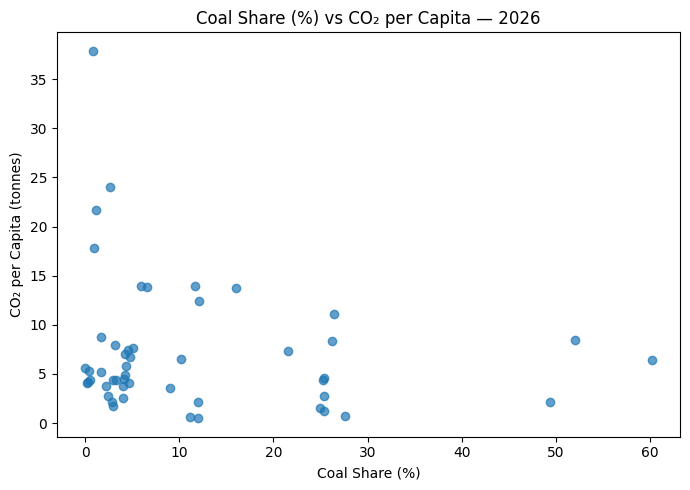

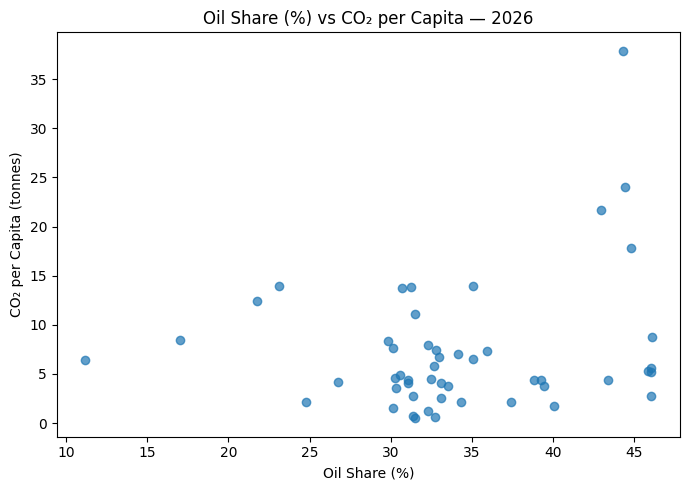

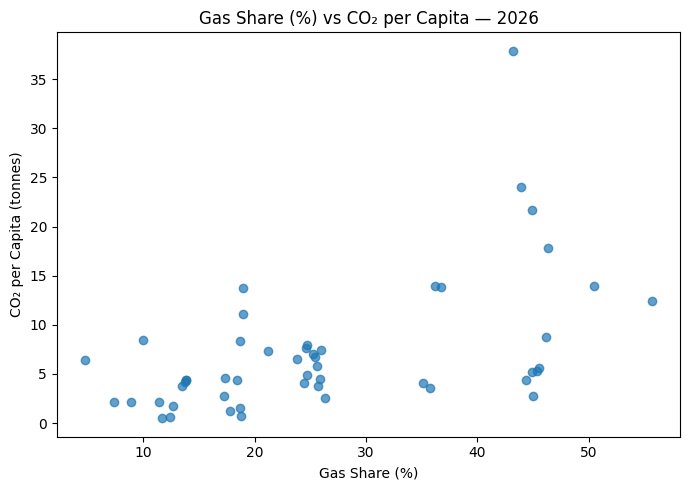

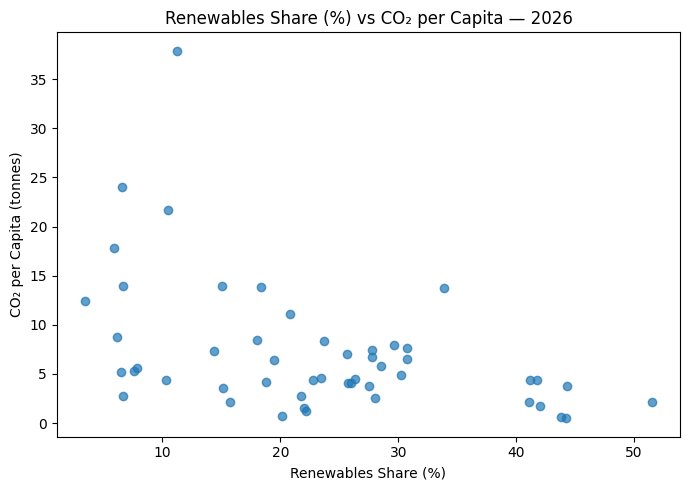

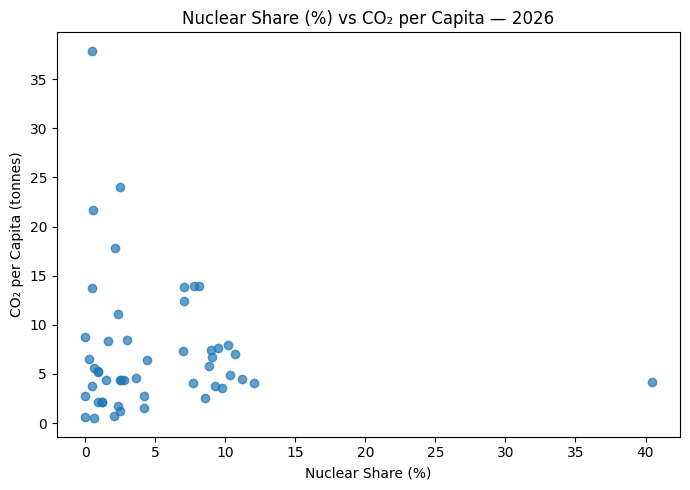

In [92]:
# ============================================================
# Q3.1 FINAL REQUIRED VISUAL
# ENERGY MIX COMPONENTS vs CO2
# ============================================================

import matplotlib.pyplot as plt

fuel_cols = [
    "coal_pct",
    "oil_pct",
    "gas_pct",
    "renewables_total_pct",
    "nuclear_pct"
]

fuel_labels = {
    "coal_pct": "Coal Share (%)",
    "oil_pct": "Oil Share (%)",
    "gas_pct": "Gas Share (%)",
    "renewables_total_pct": "Renewables Share (%)",
    "nuclear_pct": "Nuclear Share (%)"
}

latest = df3[df3["year"] == df3["year"].max()].copy()

for fuel in fuel_cols:

    plt.figure(figsize=(7, 5))

    plt.scatter(
        latest[fuel],
        latest["co2_per_capita_t"],
        alpha=0.7
    )

    plt.xlabel(fuel_labels[fuel])
    plt.ylabel("CO₂ per Capita (tonnes)")

    plt.title(
        f"{fuel_labels[fuel]} vs CO₂ per Capita — "
        f"{latest['year'].iloc[0]}"
    )

    plt.tight_layout()
    plt.show()